# **NumPy**

[NumPy user guide — numpy.org](https://numpy.org/doc/stable/user/index.html)

**Numpy** (Numerical Python) — это фундаментальный пакет для научных вычислений в Python. Он служит основой для большинства библиотек в области анализа данных и машинного обучения (pandas, scikit-learn, TensorFlow и др.).

Это библиотека предоставляет:

- **Работу с массивами** (создание, изменение формы, индексирование)
- **Математические операции** (арифметика, линейная алгебра, статистика)
- **Случайные данные** (моделирование, генераторы распределений)

В основе пакета NumPy лежит класс `ndarray`. Он инкапсулирует многомерные массивы однородных типов данных, при этом многие операции выполняются в **скомпилированном коде** для повышения производительности.

# **Типы данных**

В NumPy есть два тесно связанных, но разных понятия:

- **Классы типов данных** (`np.int32`, `np.float64`) — тип для скаляра NumPy
- **Класс** `numpy.dtype` — класс объектов с полным описанием формата данных для массива

## Классы типов данных

Это классы, описывающие **конкретный числовой или иной тип** NumPy:

- `np.int32`,
- `np.float64`,
- `np.complex128` и т.д.

Их можно использовать для создания массива:

In [ ]:
import numpy as np

np.arange(5, dtype=np.float64)
# [0. 1. 2. 3. 4.]

Инстанцирование класса вернет **скаляр NumPy**. Как правило, их не создают явно, а используют нольмерные массивы `ndarray`.

In [ ]:
import numpy as np

a = np.int32(5)  # 5
type(a)          # numpy.int32

Если же в качестве аргумента передать другой массив, то инстанцирование будет происходит **поэлементно**, а на выходе будет массив с другим `dtype`:

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.int32(10 * rng.random((3, 4)))
# [[7 4 8 6]
#  [0 9 7 7]
#  [1 4 3 9]]

a.dtype   # int32
type(a)  # <class 'numpy.ndarray'>

## Класс `numpy.dtype`

```python
dtype(obj)
```

`numpy.dtype` — это класс, объекты которого хранят **метаданные** о типе данных `obj`.

- `obj` — описание типа данных:
    - имя типа: `'int32'`, `'float64'`
    - класс NumPy: `np.int32`, `np.float64`
    - экземпляр `dtype`: `np.dtype('int32')`
    - тип Python: `int`, `float`


Можно получить явный объект `numpy.dtype`:

In [ ]:
import numpy as np

dt = np.dtype(np.float64)

isinstance(dt, np.dtype)  # True
dt.name                   # 'float64'
dt.itemsize               # 8

a = np.arange(5, dtype=dt)  # [0. 1. 2. 3. 4.]
a.dtype                     # dtype('float64')

Можно передать тип данных Python, в таком случае он **будет приведен** к типу NumPy:

| Тип Python | NumPy `dtype`                                       |
|------------|-----------------------------------------------------|
| `int`      | `int64` на 64-битных системах, `int32` на 32-битных |
| `float`    | `float64`                                           |
| `bool`     | `bool`                                              |
| `complex`  | `complex128`                                        |
| `bytes`    | `S` (`\|S0`)                                        |
| `str`      | `<U` (`<U0`)                                        |
| `object`   | `object`                                            |

## Связь между классами

Когда при создании класса мы передаем параметр `dtype`, NumPy автоматически создает объект класса `numpy.dtype` с нашим типом данных:

In [ ]:
import numpy as np

a = np.arange(5, dtype=np.int32)
b = np.arange(5, dtype=np.dtype(np.int32))
c = np.arange(5, dtype=int)

a.dtype  # dtype('int32')
b.dtype  # dtype('int32')
c.dtype  # dtype('int64'), т.к. 64-битная система

# **Класс `ndarray`**

`numpy.ndarray` — основной объект NumPy, представляющий **изменяемый и нехешируемый однородный многомерный массив**.

Существуют важные различия между массивами NumPy и стандартными последовательностями в Python:

- Массивы NumPy имеют **фиксированный размер** при создании. Изменение размера `ndarray` приведет к **созданию нового массива и удалению исходного**.
- Все элементы в массиве должны быть **одного типа данных**.

In [ ]:
import numpy as np

type(np.array([]))  # <class 'numpy.ndarray'>

a = np.array([1, 2, 3])  # [1 2 3]
a[1] = 1                 # [1 1 3]

np.array([[1, 2], [3, 4], [5, 6]])
# [[1 2]
#  [3 4]
#  [5 6]]

<div style="
  border: 1.5px solid #D7BA7D;
  background-color: #2E2A1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #FFEFC1;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

💡 **Интересный факт**

В NumPy измерения называются **осями** (axes).

</div>

## Разница между `list` и `ndarray`

Разница довольно фундаментальна, поскольку `numpy.ndarray` был в первую очередь создан как **инструмент для численных и научных вычислений**, а не как реализация конкретной структуры данных:

- **Векторные и матричные операции** — операции над массивами выполняются сразу над всеми элементами без циклов Python.
- **Хранение данных в памяти компактно и однородно** — все элементы одного типа.
- **Работа с многомерными массивами** — поддержка операций по осям, трансформаций.

## Основные атрибуты

- `ndarray.base` — исходный объект, на основе которого создан текущий массив.
- `ndarray.ndim` — количество осей (измерений) в массиве.
- `ndarray.shape` — кортеж целых целых чисел, указывающий на **размер массива в каждом измерении**. Длина кортежа равна числу осей.
- `ndarray.size` — **количество элементов в массиве**. Эквивалентно перемножению элементов кортежа `ndarray.shape`.
- `ndarray.dtype` — объект, описывающий **тип элементов** в массиве. Можно использовать стандартные типы Python или собственные типы NumPy (`numpy.int32`, `numpy.int16`, `numpy.float64` и др.)
- `ndarray.flat` — возвращает **итератор по всем элементам массива** в "плоском" виде.

In [ ]:
import numpy as np

a = np.arange(15).reshape(3, 5)
# [[ 0  1  2  3  4]
#  [ 5  6  7  8  9]
#  [10 11 12 13 14]]

a.base  # [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]

a.ndim  # 2
a.shape # (3, 5)
a.size  # 15
a.dtype # dtype('int64')

b = np.array(
    [
        [1, 2],
        [3, 4],
        [5, 6]
    ],
    dtype=np.float64)
# [[1. 2.]
#  [3. 4.]
#  [5. 6.]]

b.ndim  # 2
b.shape # (3, 2)
b.size  # 6
b.dtype  # dtype('float64')

np.array(b.flat)  # [1., 2., 3., 4., 5., 6.]

# **Copies and Views**

NumPy в целях быстроты и оптимизации вычислений жертвует одним из принципов **Zen of Python**:

> *"Explicit is better than implicit" — "Явное лучше, чем неявное".*

Например, это выражается в разной логике работы многих функций и механизмов Numpy: когда-то они возвращают **представление** (**view**), а когда-то — **копию** (**copy**).

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

Очень трудно запомнить все возможные случаи и не очень эффективно всегда проверять является ли объект копией.

1. Если с каким-то объектом будут дальнейшие манипуляции, то лучше сделать копию.
2. Если манипуляции будут с исходным массивом, то стоит это делать методами, которые **гарантируют**, что вы измените сам массив.

</div>


In [ ]:
import numpy as np

a = np.arange(5)
# [0 1 2 3 4]

b = a[:3]         # view
c = a[:3].copy()  # copy

c[0] = 100
# a = [0 1 2 3 4]
# b = [0 1 2]
# c = [100 1 2]

a[:3] *= 10 
# a = [0, 10, 20, 3, 4]
# b = [0, 10, 20]
# c = [100 1 2]

<div style="
  border: 1.5px solid #D7BA7D;
  background-color: #2E2A1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #FFEFC1;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

💡 **Интересный факт**

В отличии от объектов-представлений в стандартном Python (`dict_items`, `dict_keys`, `dict_values`), который не позволяют изменять исходный объект, в NumPy представления ссылаются на ту же память, что и оригинальный массив.

- **Изменение элементов view изменит и оригинальный массив.**
- Большие массивы можно "разрезать" на подмассивы или срезы и модифцировать без необходимости копирования данных.

</div>

Проверить, является ли массив **view** или **copy**, можно с помощью атрибута `ndarray.base`:

- `None` — **copy** (независимый массив)
- `numpy.ndarray` — **view**

In [ ]:
import numpy as np

a = np.arange(6)

b = a.reshape(2, 3)
print(b.base)       # [0, 1, 2, 3, 4, 5]
print(b.base is a)  # True

c = a.reshape(2, 3).copy()
print(c.base)       # None
print(c.base is a)  # False

## Метод `ndarray.copy`

```python
ndarray.copy()
```

Возвращает **копию** (**copy**) массива.

In [ ]:
import numpy as np

a = np.linspace(0, 5, 11)

b = a.copy()
b.base is a  # False

## Метод `ndarray.view`

```python
ndarray.view()
```

Возвращает **представление** (**view**) массива.

In [4]:
import numpy as np

a = np.linspace(0, 5, 11)
b = a.view()
b.base is a  # True

False

# **Создание массива `ndarray`**

Инстанцирование класса `ndarray` редко используется из-за большого количества параметров. Вместо этого для создания массивов используют различные **фабричные функции**:

- из существующих коллекций (`np.array`),
- генерацией последовательностей (`np.linspace`),
- инициализацией заранее заданной формы (`np.zeros`).

Почти каждая фукнция имеет необязательный ключевой параметр `dtype`, который позволяет определить тип элементов в массиве.

<div style="
  border: 1.5px solid #D7BA7D;
  background-color: #2E2A1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #FFEFC1;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

💡 **Интересный факт**

Если необходимо создать массив с формой и типом, соответствующими другому массиву, можно использовать удобные **фабричные like-функций**.

</div>

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

Если в качестве параметра передать итератор (как `zip`), NumPy порождает элементы автоматически, а рассматривает итератор как **скалярный объект** (не индексируемый) и возвращает **нольмерный массив** типа `zip`.

</div>


## Функция `numpy.array`

```python
numpy.array(object, dtype=None)
```

Позволяет создавать массивы NumPy используя **последовательности** (списки, кортежи и т.д.).

- Если передавать последовательность из последовательностей, то метод вернет **многомерный массив**.
- Если вложенные последовательности разной длины, нужно указать тип элементов как `dtype=object`.
- Если передать число, то метод вернет **нольмерный массив** (`ndim=0`).

In [ ]:
import numpy as np

np.array(0)  # 0

np.array([1, 2, 3])   # [1, 2, 3]
np.array((4, 5 , 6))  # [4, 5, 6]

np.array([[1, 2], [3, 4]])
# [[1, 2],
#  [3, 4]]

np.array([[1, 2], [3, 4]], dtype=np.float64)
# [[1. 2.]
#  [3. 4.]]

np.array([[1], [2, 3]], dtype=object)
# [list([1]) list([2, 3])]

## Функция `numpy.zeros`

```python
numpy.zeros(shape, dtype=float)
```

Возвращает массив, заполненный нулями:

In [ ]:
import numpy as np

np.zeros((2, 3)) 
# [[0. 0. 0.]
#  [0. 0. 0.]]

np.zeros((2, 3), dtype=np.int64)
# [[0 0 0]
#  [0 0 0]]

## Функция `numpy.zeros_like`

```python
numpy.zeros_like(a, dtype=None)
```

Возвращает массив с формой как у массива `a`, заполненный нулями.

## Функция `numpy.ones`

```python
numpy.ones(shape, dtype=None)
```

Возвращает массив, заполненный единицами:

In [ ]:
import numpy as np

np.ones((2, 3))
# [[1. 1. 1.]
#  [1. 1. 1.]]

np.ones((2, 3), dtype=np.int64)
# [[1 1 1]
#  [1 1 1]]

## Функция `numpy.ones_like`

```python
numpy.ones_like(a, dtype=None)
```

Возвращает массив с формой массива `a`, заполненный единицами.

## Функция `numpy.full`

```python
numpy.full(shape, fill_value, dtype=None)
```

Возвращает массив, заполненный значениями `fill_value`:

In [ ]:
import numpy as np

np.full((2, 3), 42)
# [[42 42 42]
#  [42 42 42]]

## Функция `numpy.full_like`

```python
numpy.full_like(a, fill_value, dtype=None)
```

Возвращает массив с формой массива `a`, заполненный значениями `fill_value`.

## Функция `numpy.empty`

```python
numpy.empty(shape, dtype=None)
```

Возвращает массив, заполненный с **неопределенными значениями**. Память **не инициализируется** — что лежало в байтах памяти, которые выделяются под этот массив, то и попадет в массив.

Обычно `numpy.empty` используют только тогда, когда сразу планируется записать свои данные, заменяя эти "мусорные" значения.

In [ ]:
import numpy as np

np.empty((2, 3))
# Может лежать что угодно
# [[1. 1. 1.]
#  [1. 1. 1.]]

## Функция `numpy.empty_like`

```python
numpy.empty_like(prototype, dtype=None)
```

Возвращает массив с формой массива `prototype`, заполненный с **неопределенными значениями** (как в `numpy.empty`).

## Функция `numpy.eye`

```python
numpy.eye(N, M=None, k=0, dtype=<class 'float'>)
```

Возвращает массив, заполненный единицами по диагонали и нолями в остальных местах.

- `N` — количество строк в массиве.
- `M` — количество столбцов в массиве. Если парамтер не передан, то количество столбцов соответствует `N`.
- `k` — определяет, какая диагональ будет заполнена единицами:
    - `0` — главная диагональ
    - `> 0` — диагональ выше главной (сдвиг вправо)
    - `< 0` — диагональ ниже главной (сдвиг влево)

In [ ]:
import numpy as np

a = np.eye(4, dtype=int)
# [[1 0 0 0]
#  [0 1 0 0]
#  [0 0 1 0]
#  [0 0 0 1]]

a = np.eye(4, 5, k=1, dtype=int)
# [[0 1 0 0 0]
#  [0 0 1 0 0]
#  [0 0 0 1 0]
#  [0 0 0 0 1]]

## Функция `numpy.arange`

```python
numpy.arange(stop)
numpy.arange(start=0, stop, step=1)
```

Возвращает массив из последовательности элементов от `start` (включительно) до `stop` (**не включительно**) с шагом `step`.

In [ ]:
import numpy as np

np.arange(5)
# [0 1 2 3 4]
np.arange(1, 5, 2)
# [1 3]

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

Если в качестве аргументов указать `float`, то невозможно предсказать какое количество элементов будет получено (из-за конечной точности чисел с плавающей точкой).

В таком случае лучше использовать метод `numpy.linspace`, где в качестве параметра функции выступает **количество элементов в массиве**, а не шаг.

</div>


## Функция `numpy.linspace`

```python
numpy.linspace(start, stop, num=50)
```

Возвращает массив из последовательности элементов от `start` (включительно) до `stop` (**включительно**) в количестве `num`. Шаг между элементами подбирается автоматически.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_gragh(x: np.ndarray, y: np.ndarray):
    fig, ax = plt.subplots()
    fig.patch.set_facecolor('#1a1a1a')
    ax.set_facecolor('#2a2a2a')
    ax.grid(True, color='gray', linestyle='--', alpha=0.5)
    ax.tick_params(colors='white')
    
    ax.plot(x, y, color='cyan', linewidth=2, label='sin(x)')
    ax.set_title("График sin(x)", color='white')
    ax.set_xlabel("x", color='white')
    ax.set_ylabel("sin(x)", color='white')
    ax.legend(facecolor='#1e1e1e', edgecolor='white', labelcolor='white')

    plt.show()


x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

plot_gragh(x, y)

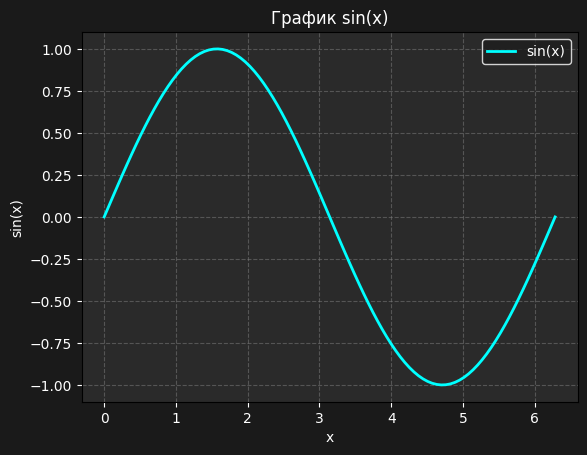

# **Индексация и срезы**

Для одномерных массивов индексация и срезы работают аналогично последовательностям `Sequence` из Python.

Многомерные массивы **имеют индекс для каждой оси**. Эти индексы приведены в виде **кортежа**.

В NumPy есть два больших режима индексирования:

- **Basic slicing** (базовое индексирование / срезы) — возвращает view массива
- **Advanced (Fancy) indexing** (расширенное индексирование) — возвращает копию массива

## Basic indexing / slicing

### Базовая индексация

**Индексация числом редуцирует массив**, сворачивая выбранные оси:

```python
a[0]    # форма (n,)
a[0:1]  # форма (1, n)
```

- Если задано меньше индексов, чем осей у массива, то каждый недостающий считается как `:` (полный срез).
- Базовая индексация поразумевает передачу кортежа из объектов, но не массивов (числа, срезы, `Ellipsis`, `None`).
- Всегда возвращает **view**.

In [ ]:
import numpy as np

def f (x, y):
    return x * 2 + y

arr = np.fromfunction(f, (3, 4), dtype=int)
# [[0 1 2 3]
#  [2 3 4 5]
#  [4 5 6 7]]

arr[2, 3]    # 7
arr[(2, 3)]  # 7
arr[-1]      # [4, 5, 6, 7]

<div style="
  border: 1.5px solid #569CD6;
  background-color: #1E1E2E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #9CDCFE;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🧠 **Вопрос**

```python
a = np.arange(9).reshape(3, 3)
# [[0 1 2]
#  [3 4 5]
#  [6 7 8]]
```

Что будет при вызове `a[(1, 2)]` и `a[(1, 2),]`?

<details><summary>ОТВЕТ</summary>

```python
a[(1, 2)]
# 5

a[(1, 2),]
# [[3 4 5]
#  [6 7 8]]
```

Выборка `a[(1, 2)]` фундаментально отличается от `a[(1, 2),]`.

- В первом случае в `__getitem__` передается кортеж из чисел `1` и `2`. Вызов аналогичен `a[1, 2]`. Это случай **basic indexing**.
- Во втором случае в `__getitem__` передается кортеж из одного объекта — другого кортежа `(1, 2)`. Это случай **fancy indexing**.

</details>
</div>

In [ ]:
import numpy as np

def f (x, y):
    return x * 2 + y

arr = np.fromfunction(f, (3, 4), dtype=int)
# [[0 1 2 3]
#  [2 3 4 5]
#  [4 5 6 7]]

arr[(1, 2)]  # 4

arr[(1, 2),]
# [[2, 3, 4, 5],
#  [4, 5, 6, 7]]

### Срезы

**Срез всегда сохраняет ось**, даже если она содержит один элемент.

- Всегда возвращает **view** (объект-представление).

Можно явно указать полный срез для всех оставшихся осей с помощью `Ellipsis` (`...`), если их много:

- `a[1, 2, ...]` эквивалентно `a[1, 2, :, :, :]`
- `a[..., 5]` эквивалентно `a[:, :, :, :, 5]`
- `a[1, ..., 4, ...]` эквивалентно `a[1, :, :, 4, :]`

In [ ]:
import numpy as np

def f (x, y):
    return x * 2 + y

arr = np.fromfunction(f, (3, 4), dtype=int)
# [[0 1 2 3]
#  [2 3 4 5]
#  [4 5 6 7]]

arr[0:1]       # [[0, 1, 2, 3]]
arr[0:1, :]    # [[0, 1, 2, 3]]
arr[0:1, ...]  # [[0, 1, 2, 3]]

arr[:-1]       # [[0, 1, 2, 3],
               #  [2, 3, 4, 5]]

Как и в случае с `Sequence`, можно указать шаг:

In [ ]:
import numpy as np

def f (x, y):
    return x * 2 + y

arr = np.fromfunction(f, (3, 4), dtype=int)
# [[0 1 2 3]
#  [2 3 4 5]
#  [4 5 6 7]]

arr[0:1, ::2]  # [[0, 2]]

arr[:-1, ::2]  # [[0, 2],
               #  [2, 4]]

**Базовое индексирование** с более чем одним элементом, отличным от `:`, в кортеже индексов работает так, как если бы мы последовательно применяли индексацию по одному такому элементу, а остальные заменяли на `:`.

Стоит помнить, что это **не работает для fancy indexing**.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

a[2, 1:3]  # [ 9, 10]
a[2][1:3]  # [ 9, 10]

Срез работает даже тогда, когда он **выходит за границы массива**. В таком случае срез вернет столько элементов, сколько ему доступно.

- Пустой массив возвращается тогда, когда ни один элемент не попал в срез.

In [ ]:
import numpy as np

a = np.arange(12)

for i in range(0, a.shape[0], 5):
    print(a[i:i+5])
# [0 1 2 3 4]
# [5 6 7 8 9]
# [10 11]

print(a[12:13])
# []

## Advanced (Fancy) indexing

**Advanced (Fancy) indexing** (расширенная индексация) возникает тогда, когда мы используем **списки, массивы индексов или булевых масок** для выборки элементов, а не простые числа, срезы или кортежи из чисел.

- Всегда возвращает **копию массива**.

<div style="
  border: 1.5px solid #569CD6;
  background-color: #1E1E2E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #9CDCFE;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🧠 **Вопрос**

А стоит ли вообще использовать запись вроде `a[(1, 2),]`?

<details><summary>ОТВЕТ</summary>

Нет. Лучше сделать запись **более явной для других разботчиков** с помощью `:` (полный срез) или `Ellipsis` (`...`): `a[(1,2), :]`

</details>
</div>

### Одномерные индексы

Можно передать массив индексов:

In [ ]:
import numpy as np

a = np.arange(12, 0, -1)
# [12 11 10  9  8  7  6  5  4  3  2  1]

idx = [7, 2, 2]

a[idx]
# [ 5, 10, 10]

Как и в случае с базовой индексацией, если количество передаваемых индексов меньше числа осей, **недостающие считаются за полный срез** `:`.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

idx = [1, 2]

a[idx]
# [[ 4,  5,  6,  7],
#  [ 8,  9, 10, 11]]

### Двумерные индексы

Для многомерного массива можно передать несколько массивов индексов:

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

rows = [1, 2]
columns = [2, 0]

a[rows, columns]  # shape → (2,)
# [6, 8]

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

**Форма результата зависит от формы массива индексов.**

</div>


In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

rows01 = [0, 1]
rows12 = [1, 2]

a[[rows01, rows12]]  # shape → (2, 2, 4)
# [[[ 0  1  2  3]
#   [ 4  5  6  7]]
#
#  [[ 4  5  6  7]
#   [ 8  9 10 11]]]

column1 = 1
column2 = 2

a[[rows01, rows12], column2]  # shape → (2, 2)
# [[ 2,  6],
#  [ 6, 10]]

a[:, [column2, column2]]  # shape → (3, 2)
# [[ 2,  2],
#  [ 6,  6],
#  [10, 10]]

a[[rows01, rows12], [column1, column2]]  # shape → (2, 2)
# [[ 1,  6],
#  [ 5, 10]]

[[0 1 2 3]
 [4 5 6 7]]
[[ 4  5  6  7]
 [ 8  9 10 11]]


array([[ 1,  6],
       [ 5, 10]])

Если количество аргументов соответствует количеству осей и все аргументы — массивы/списки **одинаковой формы**, то:

- NumPy берет компоненты **поэлементно** (element-wise)
- Результат имеет форму входных массивов индексов

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

a[[[0, 1], [1, 2]], [[1, 2], [2, 3]]]  # shape → (2, 2)
# [[ 1,  6],
#  [ 6, 11]]

### Комбинация со срезами

В кортеже можно передавать списки или массивы вместе с полным срезом `:`

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

rows = [1, 2]

a[rows, :]
# [[ 4,  5,  6,  7],
#  [ 8,  9, 10, 11]]

В случае смешивания массивов и срезов все равно будет передаваться копия массива:

In [ ]:
import numpy as np

a = np.arange(10)
# [0 1 2 3 4 5 6 7 8 9]

b = a[a > 5]
# [6 7 8 9]

b[:] = 0

print(a)  # [0 1 2 3 4 5 6 7 8 9]
print(b)  # [0 0 0 0]



### Булевы маски

Можно использовать булев массив **с broadcast-совместимой формой**.

Обычно применяется для фильтрации условий:

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 10, 12).reshape(3, 4)
# [[0 7 6 4]
#  [4 8 0 6]
#  [2 0 5 9]]

a[a > 3]
# [7 6 4 4 8 6 5 9]

a[(a > 3) & (a < 8)]
# [7 6 4 4 6 5]

mask_rows = [True, False, False]         # shape (3,)
mask_cols = [True, False, False, False]  # shape (4,)

a[mask_rows]  # [[0, 7, 6, 4]]

a[:, mask_cols]
# [[0],
#  [4],
#  [2]]

Можно передавать маску в качестве аргумента, чтобы изменять нужные элементы массива:

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 10, 12).reshape(3, 4)
# [[0 7 6 4]
#  [4 8 0 6]
#  [2 0 5 9]]

mask = a != 0

a[mask] = 2
# [[0, 2, 2, 2],
#  [2, 2, 0, 2],
#  [2, 0, 2, 2]]

Можно применять маску к отдельным строкам или столбцам:

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 10, 12).reshape(3, 4)  # shape → (3, 4)
# [[0 7 6 4]
#  [4 8 0 6]
#  [2 0 5 9]]

mask = np.array([False, True, False, False])  # shape → (4,)
mask = np.broadcast_to(mask, a.shape)         # shape → (3, 4)

a[mask] = 100
# [[  0 100   6   4]
#  [  4 100   0   6]
#  [  2 100   5   9]]

## Index Trick Objects

### `numpy.s_`

`numpy.s_` — это **специальный индексатор** или **объект-шорткат**, созданный для удобного **создания срезов** (`slice`) и индексирования.

- Позволяет писать срезы компактно и передавать их в функции, которые ожидают срезы или индексы.
- Фактически, `np.s_[...]` возвращает объект типа `slice` или кортежа из срезов, который можно использовать для индексации.
- Удобен в том случае, когда индекс массива формируется динамически.

In [ ]:
import numpy as np

a = np.arange(16).reshape(2, 2, 2, 2)
# [[[[ 0  1]
#    [ 2  3]]
#
#   [[ 4  5]
#    [ 6  7]]]
#
#
#  [[[ 8  9]
#    [10 11]]
#
#   [[12 13]
#    [14 15]]]]

a[np.s_[0, 1, :, 0]]
# [4, 6]

## Альтернатива индексации маской

Если необходимо не просто получить элементы массива, которые удовлетворяют условию, а **их индексы** для дальнейшего использования, удобно применять `np.where`.

### Функция `np.where`

```python
numpy.where(condition, [x, y], /)
```

`np.where` — очень гибкая функция, которая в зависимости от переданных аргументов может делать разные вещи.

#### Поиск индексов

```python
numpy.where(condition)
```

Проверяет выполнение условия `condition` **поэлементно**, возвращая кортеж из массивов `ndarray`, в каждый из которых записаны индексы элементов соответствующих осей.

- Всегда возвращает кортеж из массивов

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 10, 12).reshape(3, 4)
# [[0 7 6 4]
#  [4 8 0 6]
#  [2 0 5 9]]

idx = np.where(a == 0)
# (array([0, 1, 2]),
#  array([0, 2, 1]))

a[idx]
# [0, 0, 0]

#### Фильтрация с присваиванием

```python
numpy.where(condition, x, y, /)
```

Проверяет выполнение условия `condition` **поэлементно**, возвращая в зависимости от результата `x` или `y`:

- Всегда возвращает новый массив

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 10, 12).reshape(3, 4)
# [[0 7 6 4]
#  [4 8 0 6]
#  [2 0 5 9]]

np.where(a == 0, 100, a ** 2)
# [[100,  49,  36,  16],
#  [ 16,  64, 100,  36],
#  [  4, 100,  25,  81]]

# **Итерация**

Итерация многомерного массива происходит по **первой оси**. На каждой итерации возвращается **подмассив меньшей размерности** (или скаляр):

In [ ]:
def f (x, y):
    return x * 2 + y

arr = np.fromfunction(f, (3, 4), dtype=int)
# [[0 1 2 3]
#  [2 3 4 5]
#  [4 5 6 7]]

for row in arr:
    print(row)
# [0 1 2 3]
# [2 3 4 5]
# [4 5 6 7]

## Распаковка массива

Как и с другими последовательности, Python использует итерацию по объекту, то есть **итерирует массив по первой оси**:

In [ ]:
import numpy as np

a = np.arange(16).reshape(2, 2, 4)
# [[[ 0  1  2  3]
#   [ 4  5  6  7]]
#
#  [[ 8  9 10 11]
#   [12 13 14 15]]]

b, c = a

print(b)
# [[0 1 2 3]
#  [4 5 6 7]]

print(c)
# [[ 8  9 10 11]
#  [12 13 14 15]]

## Функция `numpy.ndenumerate`

`numpy.ndenumerate` — аналог класса `enumerate`, но в качестве "индекса" возвращается кортеж из индексов элемента в массиве.

In [ ]:
import numpy as np

arr = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

for idx, value in np.ndenumerate(arr):
    print(f'arr[{idx}] = {value}')
# arr[(0, 0)] = 0
# arr[(0, 1)] = 1
# arr[(0, 2)] = 2
# arr[(1, 0)] = 3
# arr[(1, 1)] = 4
# arr[(1, 2)] = 5

# **Операторы**

Арифметические и логические операции над массивами NumPy применяются **поэлементно**. При этом создается **новый массив**, который заполняется результатом.

Многие операции являются **синтаксическим сахаром** для `ufunc` (например, оператор `+` для `numpy.add`).

In [ ]:
import numpy as np

a = np.array([1, 2, 3, 4])
b = np.array([5, 6, 7, 8])

c = a - b  # [-4, -4, -4, -4]
c = a + b  # [ 6,  8, 10, 12]
c = a * b  # [ 5, 12, 21, 32]
c = a / 2  # [0.5, 1. , 1.5, 2. ]

c = a ** 2  # [ 1,  4,  9, 16]
c = a % 2   # [1, 0, 1, 0]
c = a // 2  # [0, 1, 1, 2]

c = a == 2  # [False,  True, False, False]
c = a < 3   # [ True,  True, False, False]

Для булевых массивов логические и побитовые операции применяются аналогично:

In [ ]:
import numpy as np

a = np.array([True, False, True])
b = np.array([False, False, True])

c = a & b  # [False, False,  True]
c = a | b  # [ True, False,  True]
c = a ^ b  # [ True, False, False]
c = ~a     # [ True, False,  True]

## Перемножение матриц

<div style="
  border: 1.5px solid #D7BA7D;
  background-color: #2E2A1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #FFEFC1;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

💡 **Интересный факт**

В отличии от многих других языков, оператор умножения `*` работает **поэлементно**.

Перемножение матриц реализовано с помощью оператора `@`, метода `ndarray.dot` или функции `numpy.dot`.

</div>

In [ ]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[0, 1], [2, 1]])

c = a @ b
# [[4 3]
#  [8 7]]

c = a.dot(b)
# [[4 3]
#  [8 7]]

c = np.dot(a, b)
# [[4 3]
#  [8 7]]

## Операторы `OP=`

Операторы `OP=` **мутируют** текущий массив, а не создают новый:

In [ ]:
a = np.array([1, 2, 3, 4])  # [1 2 3 4]
id(a)                       # 2187439723728

a += 1
print(a)                    # [2 3 4 5]
id(a)                       # 2187439723728

<div style="
  border: 1.5px solid #569CD6;
  background-color: #1E1E2E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #9CDCFE;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🧠 **Вопрос**

Что будет, если массив элементов `int` мутировать на месте прибавив к нему массив элементов `float`?

```python
a = np.ones((2, 3), dtype=int)
b = np.ones((2, 3))

a += b
```

<details><summary>ОТВЕТ</summary>

Если использовать оператор `+=`, то выбросит исключение, поскольку результат сложения будет `float`, который нельзя записать в массив, имеютщй тип элементов `int`.

</details>
</div>

# **Векторизация**

**Векторизация** — это подход, при котором операции выполняются не в цикле поэлементно, а сразу **над всем массивом целиком**, используя низкоуровневые оптимизации.

- Это делает код быстрее и чище.

In [ ]:
import numpy as np

a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

result = a * b  # [ 10  40  90 160]

Примером векторизированных функций в NumPy являются **универсальные функции** (`ufunc`).

In [ ]:
import numpy as np

a = np.array([1, 2, 3, 4])
b = np.array([10, 20, 30, 40])

result = np.multiply(a, b)  # [ 10  40  90 160]

# **Broadcasting**

Термин **broadcasting** описывает то, как NumPy обрабатывает массивы различной формы.

При соблюдении определенных условий меньший массив **растягивается** вдоль одной из осей, чтобы они имели **совместимые формы**.

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

Следует всегда проверять `dtype` перед векторными операциями, чтобы избежать неожиданных преобразований и лишнего расхода памяти.

</div>


## Основные правила broadcasting

При работе с двумя массивами NumPy поэлементно сравнивает их формы **с конца к началу**.

Формы **совместимы**, если на каждой позиции (двигаясь справа налево):

1. размеры осей **равны**, или
2. один из размеров осей равен `1`

Если условия не выполняются, NumPy выбросит исключение.

<div style="
  border: 1.5px solid #D7BA7D;
  background-color: #2E2A1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #FFEFC1;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

💡 **Интересный факт**

Входные массивы не обязательно должны иметь одинаковое количество осей.

Результирующий массив всегда имеет столько осей, сколько у массива **с наибольшим количеством измерений**, а размер каждой оси равен **максимуму** соответствующих размеров входных массивов.

Недостающие оси **в начале формы** считаются равными `1`.

</div>

In [ ]:
import numpy as np

a = np.arange(6).reshape(1, 2, 1, 3)  # shape → (1, 2, 1, 3)
# [[[[0 1 2]]
#
#   [[3 4 5]]]]

b = np.arange(4).reshape(4, 1)  # shape → (4, 1)
# [[0]
#  [1]
#  [2]
#  [3]]

result = a * b  # shape → (1, 2, 4, 3)
# [[[[ 0  0  0]
#    [ 0  1  2]
#    [ 0  2  4]
#    [ 0  3  6]]
#
#   [[ 0  0  0]
#    [ 3  4  5]
#    [ 6  8 10]
#    [ 9 12 15]]]]

Как происходит broadcasting в примере выше:

1. Массив `b` имеют меньшую форму, но если **добавить** две оси размера `1` в начало формы, то мы увидим, что **формы совместимы**
2. NumPy **растягивает** массив `a` по оси `2`, а `b` — по осям `0`, `1`, и `2` (считаем, что массив уже имеет 4 оси)
3. После этого происходит умножение с помощью векторизированной функции.

1. У массива `a` форма `(1, 2, 1, 3)`, а у `b` — `(4, 1)`. Чтобы их сравнить, форма массива `b` **дополняется** до `(1, 1, 4, 1)`.
2. Далее оси входных массивов сравниваются:
    - `1` и `1` → ничего не происходит
    - `2` и `1` → ось массива `b` растягивается
    - `1` и `4` → ось массива `a` растягивается
    - `3` и `1` → ось массива `b` растягивается
3. Результирующий массив будет иметь форму `(1, 2, 4, 3)`.

Операция умножения также сработает, если `b` будет иметь формы `(3,)`, `(1, 3)`, `(4, 3)`, `(1, 1)`, `(2, 4, 1)`, `(2, 4, 3)` и т.д.

## Broadcasting с массивами разных типов данных

В случае с разными типами данных применяется правило **upcasting**:

- Например, `int32` + `float64` → `float64`
- Это может влиять на память и скорость, особенно на больших массивах

In [ ]:
import numpy as np

a = np.arange(6, dtype=np.int32)
b = np.arange(6, dtype=np.float64)

result = a + b  # dtype → np.float64

## Функция `numpy.broadcast_to`

```python
numpy.broadcast_to(array, shape)
```

Явно **растягивает** массив до новой формы по правим broadcasting.

- Возвращает **read-only view**

In [ ]:
import numpy as np

a = np.arange(3)  # shape → (3,)

np.broadcast_to(a, (3, 3))
# [[0, 1, 2],
#  [0, 1, 2],
#  [0, 1, 2]]

## Пример

Удачным примером использоваться **векторизации** и **broadcasting** является поиск ближайшей точки к наблюдателю (2D).

Самый простой вариант:

- один наблюдатель, форма `(2,)`
- несколько точек, форма `(5, 2)`

In [ ]:
import numpy as np

# Координаты точек, shape → (5, 2)
points = np.array([[0, 5],
                   [0, 2],
                   [1, 8],
                   [5, 0],
                   [7, 2]])

# Коориднаты наблюдателя, shape → (2,)
observation = np.array([3, 3])

# Из каждой координаты точки вычитает соответствующую координату наблюдателя, shape → (5, 2)
diffs = points - observation               

# Вычисление расстояний, shape → (5, 1)
distances = np.sqrt(np.sum(diffs ** 2, axis=1))

# Индекс ближайшей точки
min_point = np.argmin(distances)  # shape → (0)
# 1

Более сложный вариант, когда надо найти ближайшую точку к каждому наблюдателю:

- несколько наблюдателей, форма `(4, 2)`
- несколько точек, форма `(5, 2)`

Основная проблема в том, что изначально формы несовместимы, поэтому необходимо предварительно модифировать один из массивов.

In [ ]:
import numpy as np

# Координаты точек,  shape → (5, 2)
points = np.array([[0, 5],
                   [0, 2],
                   [1, 8],
                   [5, 0],
                   [7, 2]])

# Коориднаты наблюдателей,  shape → (4, 2)
observations = np.array([[3, 3], 
                         [7, 8],
                         [4, 4],
                         [0, 0]])

# Делаем формы совместимыми
observations = observations[:, np.newaxis, :]  # shape → (4, 1, 2)

# Для каждого наблюдателя вычислениям разницу между его координатами и координатами точек
diffs = points - observations  # shape → (4, 5, 2)

# Вычисление расстояний
distances = np.sqrt(np.sum(diffs ** 2, axis=2))  # shape → (4, 5)

# Индексы ближайших точкек
min_points = np.argmin(distances, axis=1)  # shape → (4,)
# [1, 2, 4, 1]

<div style="
  border: 1.5px solid #569CD6;
  background-color: #1E1E2E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #9CDCFE;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🧠 **Вопрос**

Будет ли такое решение **эффективным по памяти**, если у нас будут десятки тысяч точек и наблюдателей?

<details><summary>ОТВЕТ</summary>

Нет, поскольку массив `diffs` может стать очень большим.

В таком случае лучше использовать **вычисления батчами** или `np.linalg.norm` без создания промежуточного трехмерного массива.

</details>
</div>

Пример батчевой обработки в случае, когда точек очень много:

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

points = rng.integers(0, 1000, (14000, 2))
observations = rng.integers(0, 1000, (4, 2))

batch_size = 1000
min_points = np.empty((4,))
min_distances = np.full((4,), np.inf, dtype=np.float32)

for i in range(0, points.shape[0], batch_size):
    # Создаем батч из 1000 точек и вычисляем все расстоя между точками и наблюдателями
    points_batch = points[i:i + batch_size]
    diffs_batch = points_batch - observations[:, None, :]        # shape → (4, 1000, 2)
    distances_batch = np.sqrt(np.sum(diffs_batch ** 2, axis=2))  # shape → (4, 1000)
    
    # Рассчитываем значение минимальных расстояний и их индексы в текущем батче
    min_distances_batch = np.min(distances_batch, axis=1)      # shape → (4,)
    min_points_batch = i + np.argmin(distances_batch, axis=1)  # shape → (4,)

    # С помощью маски определяем какие дистанции и индексы из текущего батча нужно записать во внешние переменные
    mask_distances_batch = min_distances_batch < min_distances
    min_distances[mask_distances_batch] = min_distances_batch[mask_distances_batch]
    min_points[mask_distances_batch] = min_points_batch[mask_distances_batch]

min_points = min_points.astype(int)
# [11061  4106  9954   426]

# **Манипуляции с формой**

## Добавление и удаление элементов

### Функция `numpy.append`

```python
numpy.append(arr, values, axis=None)
```

Возвращает **новый массив** с добавлением значений `values` вдоль оси `axis`.

- Если `axis=None`, то делает массив одномерным и добавляет все значения `values` в конец массива.
- Если `axis` — число, то `values` должен иметь **совместимую форму** с `arr`.
- Не меняет `arr`, а **создает его копию**, что может быть неэффективно по памяти для больших массивов.

In [ ]:
import numpy as np

a = np.arange(4).reshape(2, 2)
# [[0 1]
#  [2 3]]
# shape → (2, 2)

np.append(a, [[4], [5]])
# [0 1 2 3 4 5]
# shape → (5,)

np.append(a, [[4], [5]], axis=1)
# [[0, 1, 4],
#  [2, 3, 5]]
# shape → (2, 3)

np.append(a, [[4, 5]], axis=0)
# [[0, 1],
#  [2, 3],
#  [4, 5]]
# shape → (3, 2)

### Функция `numpy.insert`

```python
numpy.insert(arr, obj, values, axis=None)
```

Возвращает **новый массив** с добавлением значений `values` вдоль оси `axis` с индексами, указанными в `obj`.

- Если `axis=None`, то делает массив одномерным, а затем вставляет значения согласно `obj` по одномерной версии.
- Если `axis` — число, добавляемая структура **должна быть согласована по остальным осям**.
- Не меняет `arr`, а **создает его копию**, что может быть неэффективно по памяти для больших массивов.
- Если `obj` — массив индексов, вставка происходит последовательно слева направо, и каждая вставка сдвигает элементы справа.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]
# shape → (2, 3)

np.insert(a, 2, 99)
# [ 0,  1, 99,  2,  3,  4,  5]
# shape → (7,)

print(np.insert(a, [0, 1], [10, 11, 12], axis=0))
# [[10 11 12]
#  [ 0  1  2]
#  [10 11 12]
#  [ 3  4  5]]
# shape → (4, 3)

np.insert(a, 2, [6, 7], axis=1)
# [[0, 1, 6, 2],
#  [3, 4, 7, 5]]
# shape → (2, 4)

np.insert(a, [1, 1], 8, axis=1)
# [[0, 8, 8, 1, 2],
#  [3, 8, 8, 4, 5]]
# shape → (2, 5)

obj    = [1, 2]
values = [[6, 7],
          [8, 9]]

np.insert(a, obj, values, axis=1)
# [[0, 6, 1, 7, 2],
#  [3, 8, 4, 9, 5]]
# shape → (2, 5)

### Функция `numpy.delete`

```python
numpy.delete(arr, obj, axis=None)
```

Возвращает **новый массив** без элементов с индексами из `obj` вдоль оси `axis`.

- Если `axis=None`, то делает массив одномерным и удаляет значения согласно `obj` по одномерной версии.
- Не меняет `arr`, а **создает его копию**, что может быть неэффективно по памяти для больших массивов.
- `obj` может быть срезом.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

np.delete(a, slice(2, 9))
# [ 0,  1,  9, 10, 11]

np.delete(a, 1, axis=0)
# [[ 0,  1,  2,  3],
#  [ 8,  9, 10, 11]]

np.delete(a, (1, 2), axis=1)
# [[ 0,  3],
#  [ 4,  7],
#  [ 8, 11]]

## Индексация для изменения формы

Если необходимо добавить новые оси, это можно сделать с помощью `None` или псевдоним `np.newaxis`:

In [ ]:
import numpy as np

a = np.arange(6)
# [0 1 2 3 4 5]
a.shape  # (6,)

b = a[np.newaxis, :]
# [[0 1 2 3 4 5]]
b.shape  # (1, 6)

c = a[:, np.newaxis]
# [[0]
#  [1]
#  [2]
#  [3]
#  [4]
#  [5]]
c.shape  # (6, 1)

## Методы массива

### Метод `ndarray.ravel`

```python
ndarray.ravel()
```

Это метод массива, который "разворачивает" его в **одномерный массив**.

- Возвращает **view массива**, если возможно, иначе копию.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.int32(10 * rng.random((3, 4)))
# [[7 4 8 6]
#  [0 9 7 7]
#  [1 4 3 9]]

a.ravel()  # [7, 4, 8, 6, 0, 9, 7, 7, 1, 4, 3, 9]

### Метод `ndarray.flatten`

```python
ndarray.flatten()
```

Это метод массива, который "разворачивает" его в **одномерный массив**.

- **Всегда возвращает копию**.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.int32(10 * rng.random((3, 4)))
# [[7 4 8 6]
#  [0 9 7 7]
#  [1 4 3 9]]

a.flatten()  # [7, 4, 8, 6, 0, 9, 7, 7, 1, 4, 3, 9]

### Метод `ndarray.reshape`

```python
ndarray.reshape(shape)
```

Возвращает **view** массива **с другой формой**, если это возможно, иначе копию.

- Общее количество элементов должно совпадать.
- Для автоматического вычисления размера **одной из осей** можно подставить `-1`.
- `ndarray.reshape` не создает новый буфер, а лишь **действует на существующий**, если возможно.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0,  1,  2,  3],
#  [ 4,  5,  6,  7],
#  [ 8,  9, 10, 11]]

b = a.reshape(-1, 6).copy()
# [[ 0  1  2  3  4  5]
#  [ 6  7  8  9 10 11]]

### Метод `ndarray.resize`

```python
ndarray.resize(new_shape)
```

**Мутирует** массив, изменяя его форму.

- Если новая форма больше исходной, **массив дозаполняется нулями**.
- `ndarray.resize` может выделять новый буфер, если количество элементов будет больше, то есть метод **требует, чтобы массив сам владел своим буфером** (не был view)

Повеледние метода отличается от фунции `numpy.resize`.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4).copy()
# [[ 0,  1,  2,  3],
#  [ 4,  5,  6,  7],
#  [ 8,  9, 10, 11]]

a.resize(3, 6)
print(a)
# [[ 0  1  2  3  4  5]
#  [ 6  7  8  9 10 11]
#  [ 0  0  0  0  0  0]]

<div style="
  border: 1.5px solid #569CD6;
  background-color: #1E1E2E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #9CDCFE;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🧠 **Вопрос**

Что случится, если не использовать копирование, а оставить массив `a` в качестве **view**?

```python
a = np.arange(12).reshape(3, 4)
a.resize(3, 6)
```

<details><summary>ОТВЕТ</summary>

**Python выбросит ошибку.**

В данном случае массив `a` — это **view**, и он **не владеет своим буфером**. Метод не может изменить форму такого массива, поскольку ему нужно выделить новый буфер под новые элементы, что невозможно.

</details>
</div>

### Метод `ndarray.transpose`

```python
ndarray.transpose(*axes)
```

Меняет **порядок осей массива**.

- Возвращает **view**, если это возможно, иначе копию.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.arange(24).reshape(2, 3, 4)
# [[[ 0  1  2  3]
#   [ 4  5  6  7]
#   [ 8  9 10 11]]
#
#  [[12 13 14 15]
#   [16 17 18 19]
#   [20 21 22 23]]]

a = a.transpose(2, 0, 1)
# [[[ 0  4  8]
#   [12 16 20]]
#
#  [[ 1  5  9]
#   [13 17 21]]
#
#  [[ 2  6 10]
#   [14 18 22]]
#
#  [[ 3  7 11]
#   [15 19 23]]]

## Свойства массива

### Свойство `ndarray.flat`

Возвращает **итератор**, который при итерации **порождает** элементы массива, как если бы он был одномерным.

- Это **не view и не копия массива**.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.array(10 * rng.random((3, 4)), dtype=int)
# [[7 4 8 6]
#  [0 9 7 7]
#  [1 4 3 9]]

np.array(a.flat)  # [7, 4, 8, 6, 0, 9, 7, 7, 1, 4, 3, 9]

### Свойство `ndarray.T`

`ndarray.T` — это синтаксический сахар для `ndarray.transpose`.

- В случае с двумерным массивом возвращает то же самое, что и `ndarray.transpose`.
- В случае с многомерным массивом **инвертирует оси** (идут в обратном порядке).
- Возвращает **view**, если это возможно, иначе копию.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

a.T
# [[ 0,  4,  8],
#  [ 1,  5,  9],
#  [ 2,  6, 10],
#  [ 3,  7, 11]]

## Функции верхнего уровня

Основное отличие функций от похожий bound-методов массива `ndarray` — работа не только с массивами, а с любыми array-like объектами.

### Функция `np.ravel`

```python
numpy.ravel(a)
```

Является полным аналогом метода `ndarray.ravel`.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

b = np.ravel(a).copy()
# [ 0  1  2  3  4  5  6  7  8  9 10 11]

### Функция `np.reshape`

```python
numpy.reshape(a, /, shape=None)
```

Является полным аналогом метода `ndarray.reshape`.

In [ ]:
import numpy as np

a = np.arange(12)
# [ 0  1  2  3  4  5  6  7  8  9 10 11]

b = np.reshape(a, (3, 4)).copy()
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

### Функция `np.resize`

```python
numpy.resize(a, new_shape)
```

**Создает копию массива**, изменяя его форму.

- Если новая форма больше исходной, **массив повторяет элементы**.
- Переданный массив **может быть view**.

Поведение функции отличается от метода `ndarray.resize`.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0,  1,  2,  3],
#  [ 4,  5,  6,  7],
#  [ 8,  9, 10, 11]]

b = np.resize(a, (3, 6))
print(b)
# [[ 0  1  2  3  4  5]
#  [ 6  7  8  9 10 11]
#  [ 0  1  2  3  4  5]]

### Функция `np.transpose`

```python
numpy.transpose(a, axes=None)
```

Является полным аналогом метода `ndarray.transpose`.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.arange(24).reshape(2, 3, 4)
# [[[ 0  1  2  3]
#   [ 4  5  6  7]
#   [ 8  9 10 11]]
#
#  [[12 13 14 15]
#   [16 17 18 19]
#   [20 21 22 23]]]

b = np.transpose(a, (2, 0, 1))
# [[[ 0  4  8]
#   [12 16 20]]
#
#  [[ 1  5  9]
#   [13 17 21]]
#
#  [[ 2  6 10]
#   [14 18 22]]
#
#  [[ 3  7 11]
#   [15 19 23]]]

# **Объединение массивов**

## Функции верхнего уровня

### Функция `numpy.vstack`

```python
numpy.vstack(tup, *, dtype=None)
```

Возвращает **новый массив**, полученный **вертикальной склейкой (row-wise)** всех массивов по оси `0`.

- Если массив формы `(N,)`, то он преобразуется в двумерный массив с формой `(1, N)` перед склейкой.
- Поддерживает любые не нольмерные массивы, главное, чтобы у них **совпадали `1`, `2` и последующие оси**.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.array(10 * rng.random((2, 4)), dtype=int)
# [[7 4 8 6]
#  [0 9 7 7]]
# shape → (2, 4)

b = np.array(10 * rng.random(4), dtype=int)
# [1 4 3 9]
# shape → (4,)

c = np.vstack((a, b))
# [[7 4 8 6]
#  [0 9 7 7]
#  [1 4 3 9]]
# shape → (3, 4)

Более сложный случай с трехмерными массивами:

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.array(10 * rng.random((2, 2, 3)), dtype=int)
# [[[7 4 8]
#   [6 0 9]]
#
#  [[7 7 1]
#   [4 3 9]]]
# shape → (2, 2, 3)

b = np.array(10 * rng.random((2, 3)), dtype=int)
# [[6 8 4]
#  [2 5 0]]]
# shape → (2, 3)

c = np.vstack((a, b[np.newaxis, :]))
# [[[7 4 8]
#   [6 0 9]]
#
#  [[7 7 1]
#   [4 3 9]]
#
#  [[6 8 4]
#   [2 5 0]]]
# shape → (3, 2, 3)

### Функция `numpy.hstack`

```python
numpy.hstack(tup, *, dtype=None)
```

Возвращает **новый массив**, полученный **горизонтальной склейкой (column-wise)** всех массивов по оси `1`.

- Массивы с формой `(N,)` нужно **явно преобразовать** в двумерный массив с формой `(N, 1)`.
- Поддерживает любые двумерные и более массивы, главное, чтобы у них **совпадали `0`, `2`, `3` и последующие оси**.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.array(10 * rng.random((4, 2)), dtype=int)
# [[7 4]
#  [8 6]
#  [0 9]
#  [7 7]]
# shape → (4, 2)

b = np.array(10 * rng.random(4), dtype=int).reshape(4, 1)
# [[1]
#  [4]
#  [3]
#  [9]]
# shape → (4, 1)

c = np.hstack((a, b))
# [[7 4 1]
#  [8 6 4]
#  [0 9 3]
#  [7 7 9]]
# shape → (4, 3)

Более сложный случай с трехмерными массивами:

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.array(10 * rng.random((2, 3, 2)), dtype=int)
# [[[7 4]
#   [8 6]
#   [0 9]]

#  [[7 7]
#   [1 4]
#   [3 9]]]
# shape → (2, 3, 2)

b = np.array(10 * rng.random((2, 1, 2)), dtype=int)
# [[[6 8]]
#
#  [[4 2]]]
# shape → (2, 1, 2)

c = np.hstack((a, b))
# [[[7 4]
#   [8 6]
#   [0 9]
#   [6 8]]
#
#  [[7 7]
#   [1 4]
#   [3 9]
#   [4 2]]]
# shape → (2, 4, 2)

### Функция `numpy.dstack`

```python
numpy.dstack(tup, *, dtype=None)
```

Возвращает **новый массив**, полученный **глубинной склейкой (deep-wise)** всех массивов по оси `2`.

- Если массив формы `(N,)`, то он преобразуется в трехмерный массив с формой `(1, N, 1)` перед склейкой.
- Поддерживает любые не нольмерные массивы, главное, чтобы у них **совпадали `0`, `1`, `3`, `4` и последующие оси**.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.array(10 * rng.random((2, 2, 3)), dtype=int)
# [[[7 4 8]
#   [6 0 9]]
#
#  [[7 7 1]
#   [4 3 9]]]
# shape → (2, 2, 3)

b = np.array(10 * rng.random((2, 2, 1)), dtype=int)
# [[[6]
#   [8]]
#
#  [[4]
#   [2]]]
# shape → (2, 2, 1)

c = np.dstack((a, b))
# [[[7 4 8 6]
#   [6 0 9 8]]
#
#  [[7 7 1 4]
#   [4 3 9 2]]]
# shape → (2, 2, 4)

### Функция `numpy.row_stack`

Является эквивалентом `numpy.vstack`.

- Используется для большие читаемости.

### Функция `numpy.column_stack`

Является эквивалентом `numpy.hstack`, **но без необходимости в дополнительной манипуляции формой**:

- Если массив формы `(N,)`, то он преобразуется в двумерный массив с формой `(N, 1)` перед склейкой.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = np.array(10 * rng.random((4, 2)), dtype=int)
# [[7 4]
#  [8 6]
#  [0 9]
#  [7 7]]
# shape → (4, 2)

b = np.array(10 * rng.random(4), dtype=int)
# [1 4 3 9]

c = np.column_stack((a, b))
# [[7 4 1]
#  [8 6 4]
#  [0 9 3]
#  [7 7 9]]
# shape → (4, 3)

### Функция `numpy.concatenate`

```python
numpy.concatenate((a1, a2, ...), axis=0, out=None, dtype=None)
```

Возвращает **новый массив**, полученный **склейкой** всех массивов по указанной оси `axis`.

- Массивы обязательно должны иметь одинаковую форму **по всем осям, кроме той, по которой склеиваем**.
- **Не делает никаких автоматических преобразований формы**, как другие аналогичные функции.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

b = np.arange(6, 12).reshape(2, 3)
# [[ 6  7  8]
#  [ 9 10 11]]

c = np.arange(12, 16).reshape(2, 2, 1)
# [[[12]
#   [13]]
#
#  [[14]
#   [15]]]

final = np.concatenate((a[np.newaxis, :], b[np.newaxis, :]), axis=0)
# [[[ 0  1  2]
#   [ 3  4  5]]
#
#  [[ 6  7  8]
#   [ 9 10 11]]]

final = np.concatenate((final, c), axis=2)
# [[[ 0  1  2 12]
#   [ 3  4  5 13]]
#
#  [[ 6  7  8 14]
#   [ 9 10 11 15]]]

### Функция `numpy.stack`

```python
numpy.stack(arrays, axis=0, out=None, *, dtype=None)
```

Возвращает **новый массив**, полученный **склейкой** всех массивов **по новой оси**, которая добавляется на позицию `axis`.

- Все массивы **должны иметь одинаковую форму**.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

b = np.arange(6, 12).reshape(2, 3)
# [[ 6  7  8]
#  [ 9 10 11]]

c = np.stack((a, b), axis=0)
# [[[ 0  1  2]
#   [ 3  4  5]]
#
#  [[ 6  7  8]
#   [ 9 10 11]]]

d = np.stack((a, b), axis=1)
# [[[ 0  1  2]
#   [ 6  7  8]]
#
#  [[ 3  4  5]
#   [ 9 10 11]]]

e = np.stack((a, b), axis=2)
# [[[ 0  6]
#   [ 1  7]
#   [ 2  8]]
#
#  [[ 3  9]
#   [ 4 10]
#   [ 5 11]]]

## **Index Trick Objects**

### Синглтон `numpy.r_`

`numpy.r_` — это **специальный индексатор** или **объект-шорткат**, созданный для удобного индексирования и генерации массивов. Синтаксический сахар для склейки по первой оси.

- Для одмерных аргументов (скаляров и срезов) делает конкатенцию вдоль единственной оси (`axis=0`) и результат остается одномерным.
- Для двумерных массивов делает **склейку по строкам** (row-wise, аналог `numpy.row_stack`).

In [ ]:
import numpy as np

np.r_[1:4, 5, 6:9, np.arange(3)]
# [1 2 3 5 6 7 8 0 1 2]

a = np.arange(3).reshape(1, 3)
b = np.arange(3, 6).reshape(1, 3)

np.r_[a, b]
# [[0 1 2]
#  [3 4 5]]

### Синглтон `numpy.c_`

`numpy.c_` — это **специальный индексатор** или **объект-шорткат**, созданный для удобного индексирования и генерации массивов. Синтаксический сахар для склейки по второй оси.

- Преобразует скаляры и срезы в одномерные массивы.
- **Склеивает по столбцам** (column-wise, аналог `numpy.column_stack`).

In [ ]:
import numpy as np

np.c_[0:2, 1:3, 2:4]
# [[0 1 2]
#  [1 2 3]]

a = np.arange(3)
b = np.arange(3, 6)

np.c_[a, b]
# [[0 3]
#  [1 4]
#  [2 5]]

np.c_[a[np.newaxis, :], b[np.newaxis, :]]
# [[0 1 2 3 4 5]]

# **Разделение массивов**

## Функция `numpy.split`

```python
numpy.split(ary, indices_or_sections, axis=0)
```

Возвращает **список подмассивов**, разделяя массив `ary` вдоль оси `axis`.

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

Все подмассивы — **представления** (view), если это возможно. Иначе **копии** (copy).

</div>


Функции `numpy.vsplit`, `numpy.hsplit`, `numpy.dsplit` являются аналогами и используются тогда, когда необходимо подчеркнуть по какой оси происходит разделение.

- `indices_or_sections` может быть:
    - **целое число** — на сколько равных частей разделить (если число не делит размерность по оси `axis` нацело — выбросит ошибку);
    - **последовательность индексов** — задает точки разреза для подмассивов.
- Каждый подмассив сохраняет то же количество осей.

In [ ]:
import numpy as np

a = np.arange(12).reshape(4, 3)
# [[ 0  1  2]
#  [ 3  4  5]
#  [ 6  7  8]
#  [ 9 10 11]]

np.split(a, 2)
# [array([[0, 1, 2],
#         [3, 4, 5]]),
#  array([[ 6,  7,  8],
#         [ 9, 10, 11]])]

np.split(a, 3, axis=1)
# [array([[0],
#         [3],
#         [6],
#         [9]]),
#  array([[ 1],
#         [ 4],
#         [ 7],
#         [10]]),
#  array([[ 2],
#         [ 5],
#         [ 8],
#         [11]])]

### Особенности разделения `indices_or_sections`

**Последовательность индексов** имеет одну и ту же логику разделения дня всех представленных функций:

- Для каждого индекса **берётся подмассив между предыдущим и текущим индексом**;
- Если текущий индекс меньше предыдущего, то подмассив будет пустым;
- Если последний индекс совпадает с длиной массива, то последний подмассив будет пустым.

In [ ]:
import numpy as np

a = np.arange(12).reshape(4, 3)
# [[ 0  1  2]
#  [ 3  4  5]
#  [ 6  7  8]
#  [ 9 10 11]]

np.split(a, (3,))
# [array([[0, 1, 2],
#         [3, 4, 5],
#         [6, 7, 8]]),
#  array([[ 9, 10, 11]])]

np.split(a, (4,))
# [array([[ 0,  1,  2],
#         [ 3,  4,  5],
#         [ 6,  7,  8],
#         [ 9, 10, 11]]),
#  array([], shape=(0, 3), dtype=int64)]

np.split(a, (3, 4))
# [array([[0, 1, 2],
#         [3, 4, 5],
#         [6, 7, 8]]),
#  array([[ 9, 10, 11]]),
#  array([], shape=(0, 3), dtype=int64)]

np.split(a, (2, 1))
# [array([[0, 1, 2],
#         [3, 4, 5]]),
#  array([], shape=(0, 3), dtype=int64),
#  array([[ 3,  4,  5],
#         [ 6,  7,  8],
#         [ 9, 10, 11]])]

## Функция `numpy.vsplit`

```python
numpy.vsplit(ary, indices_or_sections)
```

Возвращает **список подмассивов**, разделяя массив `ary` вдоль оси `0`.

- `indices_or_sections` может быть:
    - **целое число** — на сколько равных частей разделить (если число не делит размерность по оси `0` нацело — выбросит ошибку);
    - **последовательность индексов** — задает точки разреза для подмассивов.
- Каждый подмассив сохраняет то же количество осей.
- Массив `ary` должен иметь хотя бы 2 оси.

In [ ]:
import numpy as np

a = np.arange(12).reshape(4, 3)
# [[ 0  1  2]
#  [ 3  4  5]
#  [ 6  7  8]
#  [ 9 10 11]]

np.vsplit(a, 4)
# [array([[0, 1, 2]]),
#  array([[3, 4, 5]]),
#  array([[6, 7, 8]]),
#  array([[ 9, 10, 11]])]

np.vsplit(a, 2)
# [array([[0, 1, 2],
#         [3, 4, 5]]),
#  array([[ 6,  7,  8],
#         [ 9, 10, 11]])]

## Функция `numpy.hsplit`

```python
numpy.hsplit(ary, indices_or_sections)
```

Возвращает **список подмассивов**, разделяя массив `ary` вдоль оси `1`.

- `indices_or_sections` может быть:
    - **целое число** — на сколько равных частей разделить (если число не делит размерность по оси `1` нацело — выбросит ошибку);
    - **последовательность индексов** — задает точки разреза для подмассивов.
- Каждый подмассив сохраняет то же количество осей.
- Для одномерного массива `ary` разделение происходит по оси `0`.

In [ ]:
import numpy as np

a = np.arange(8).reshape(2, 4)
# [[0 1 2 3]
#  [4 5 6 7]]

np.hsplit(a, 2)
# [array([[0, 1],
#         [4, 5]]),
#  array([[2, 3],
#         [6, 7]])]

np.hsplit(a, (3,))
# [array([[0, 1, 2],
#         [4, 5, 6]]),
#  array([[3],
#         [7]])]

Сравнение с одномерным случаем:

In [ ]:
import numpy as np

a = np.arange(4)
# [0 1 2 3], shape → (4,)

np.hsplit(a, 2)
# [array([0, 1]),
#  array([2, 3])]

a = a[np.newaxis, :]
# [[0 1 2 3]], shape → (1, 4)

np.hsplit(a, 2)
# [array([[0, 1]]),
#  array([[2, 3]])]

## Функция `numpy.dsplit`

```python
numpy.dsplit(ary, indices_or_sections)
```

Возвращает **список подмассивов**, разделяя массив `ary` вдоль оси `2`.

- `indices_or_sections` может быть:
    - **целое число** — на сколько равных частей разделить (если число не делит размерность по оси `2` нацело — выбросит ошибку);
    - **последовательность индексов** — задает точки разреза для подмассивов.
- Каждый подмассив сохраняет то же количество осей.
- Массив `ary` должен иметь хотя бы 3 оси.

In [ ]:
import numpy as np

a = np.arange(12).reshape(2, 2, 3)
# [[[ 0  1  2]
#   [ 3  4  5]]
#
#  [[ 6  7  8]
#   [ 9 10 11]]]

np.dsplit(a, 3)
# [array([[[0],
#          [3]],
#
#         [[6],
#          [9]]]),
#  array([[[ 1],
#          [ 4]],
#
#         [[ 7],
#          [10]]]),
#  array([[[ 2],
#          [ 5]],
#
#         [[ 8],
#          [11]]])]

## Функция `numpy.array_split`

```python
numpy.array_split(ary, indices_or_sections, axis=0)
```

Аналог `numpy.split`.

Единственное различие заключается в том, что в качестве эта функция позволяет передать `indices_or_sections` целое число, которое **не делит нацело** размерность по оси `axis`. В таком случае несколько подмассивов (начиная с первого) будут иметь на один элемент больше.

In [ ]:
import numpy as np

a = np.arange(12).reshape(4, 3)
# [[ 0  1  2]
#  [ 3  4  5]
#  [ 6  7  8]
#  [ 9 10 11]]

np.array_split(a, 3)
# [array([[0, 1, 2],
#         [3, 4, 5]]),
#  array([[6, 7, 8]]),
#  array([[ 9, 10, 11]])]

# **Унарные редукции**

**Унарные редукции** (агрегаторы) — это **унарные операции**, которые применяются к одному массиву и **редуцируют его по одной из осей**, приводя к массиву меньшей размерности или скаляру.

In [ ]:
import numpy as np

a = np.array([1, 2, 3, 4])  # [1 2 3 4]

a.sum()                      # 10
np.sum(a)                    # 10
np.add.reduce(a, axis=None)  # 10

В случае скаляра мы на самом деле приводим массив **нольмерному массиву** — массиву **без осей**, который является полноценным `numpy.ndarray`, а его форма равна `()`.

In [ ]:
import numpy as np

a = np.array(0)  # 0
a.size   # 1
a.shape  # ()
a.dtype  # dtype('int64')
type(a)  # numpy.ndarray

## Реализации унарных редукций

В NumPy унарные редукции реализованы как:

- **Методы массива** — используются почти всегда, если работаем с **конкретным массивом**.
- **Функции верхнего уровня** — используется, когда необходимо работать с **любыми последовательностями**, а не только `ndarray`.
- **NaN-safe функции** — те же самые функции верхнего порядка, но игнорируют `np.nan`.
- **Метод `reduce` объектов `ufunc`** — используются при написании универсальных функций, когда важна совместимость с любыми `ufunc`.

<div style="
  border: 1.5px solid #D7BA7D;
  background-color: #2E2A1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #FFEFC1;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

💡 **Интересный факт**

В терминологии NumPy **редукция** — это применение **унарной универсальной функции** (`ufunc`) по заданной оси.

Но на практике не все функции или методы, редуцирующие массив, реализованы через `ufunc`: некоторые реализованы на Python/С-уровне.

</div>

| Метод массива    | Функция верхнего уровня | NaN-safe функции      | Метод `reduce` объекта `ufunc` |
| ---------------- | ----------------------- | --------------------- | ------------------------------ |
| `ndarray.sum`    | `numpy.sum`             | `numpy.nansum`        | `np.add.reduce`                |
| `ndarray.prod`   | `numpy.prod`            | `numpy.nanprod`       | `np.multiply.reduce`           |
| `ndarray.mean`   | `numpy.mean`            | `numpy.nanmean`       | -                              |
| `ndarray.var`    | `numpy.var`             | `numpy.nanvar`        | -                              |
| `ndarray.std`    | `numpy.std`             | `numpy.nanstd`        | -                              |
| `ndarray.min`    | `numpy.min`             | `numpy.nanmin`        | `np.minimum.reduce`            |
| `ndarray.max`    | `numpy.max`             | `numpy.nanmax`        | `np.maximum.reduce`            |
| `ndarray.argmin` | `numpy.argmin`          | `numpy.nanargmin`     | -                              |
| `ndarray.argmax` | `numpy.argmax`          | `numpy.nanargmax`     | -                              |
| `ndarray.any`    | `numpy.any`             | -                     | `np.logical_or.reduce`         |
| `ndarray.all`    | `numpy.all`             | -                     | `np.logical_and.reduce`        |
| `ndarray.trace`  | `numpy.trace`           | -                     | -                              |
| -                | `numpy.ptp`             | `numpy.nanptp`        | -                              |
| -                | `numpy.median`          | `numpy.nanmedian`     | -                              |
| -                | `numpy.percentile`      | `numpy.nanpercentile` | -                              |
| -                | `numpy.quantile`        | `numpy.nanquantile`   | -                              |

## Параметры методов 

Унарные редукции поддерживают похожий набор **ключевых параметров**.

### Параметр `axis`

Определяет по каким осям выполнять редуцирование.

- Может быть `None` (по умолчанию для **оберток** — редуцирование по всем осям), `int` (одна ось) или `tuple[int, ...]` (несколько осей)
- Допустимы **отрицательные значения** по аналогии с отрицательными индексами в списках (`axis=-1` — последняя ось)
 - В случае с кортежем редуцирование происходит в порядке указанных осей

In [ ]:
import numpy as np

a = np.arange(24).reshape(2, 3, 4)
# [[[ 0  1  2  3]
#   [ 4  5  6  7]
#   [ 8  9 10 11]]
#
#  [[12 13 14 15]
#   [16 17 18 19]
#   [20 21 22 23]]]

a.sum(axis=0)
# [[12 14 16 18]
#  [20 22 24 26]
#  [28 30 32 34]]

b = a.sum(axis=1)
# [[12 15 18 21]
#  [48 51 54 57]]

b = a.sum(axis=-1)
# [[ 6 22 38]
#  [54 70 86]]

a.sum(axis=(1, 2))
# [ 66, 210]

### Параметр `dtype`

Определяет тип выходного массива и **промежуточных вычислений**.

- Если `None`, то тип выбирается автоматически.

In [ ]:
import numpy as np

a = np.array([[0.9, 0.9, 0.9], [0.9, 0.9, 0.9]])

np.sum(a, dtype=int)  # 0

### Параметр `out`

Массив, в который будет записан результат.

- **Должен иметь совместимую форму и тип**
- Если `None`, NumPy создает новый массив.
- Если `out` передан, то метод использует **существующее место в памяти**. Это экономит память и ускоряет многократные вычисления.

In [ ]:
import numpy as np

a = np.arange(5)
sum = a.sum()  # создается новый объект

b = np.empty_like(a)
a.sum(out=b)  # тот же объект

### Параметр `keepdims`

Определяет, останется ли редуцируемая ось в виде оси размерности `1`.

- Если `False` (по умолчанию) — ось редуцируется, ее размерность исчезает.
- Если `True` — редуцируемая ось сохраняется с размерностью `1`, а форма результата **будет совместима** с исходным массивом для последующих операций с **broadcasting**.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.sum(axis=0)                 # [3 5 7], shape=(3,)
a.sum(axis=0, keepdims=True)  # [[3 5 7]], shape=(1, 3)

### Параметр `initial`

Начальное значение для редукции (стартовое значение аккумулятора).

- Для методов `ndarray.min` и `ndarray.max` может задать начальные границы.

In [ ]:
import numpy as np

a = np.arange(5)  # [0 1 2 3 4]

a.sum(initial=10)  # 20
a.min(initial=-5)  # -5

### Параметр `where`

Булевая маска, которая должна быть **broadcast-совместима** с массивом.

- Определяет, какие элементы участвуют в редукции (`True` — учитывать, `False` — пропускать)
- По умолчанию — `True`

In [ ]:
import numpy as np

rng = np.random.default_rng(42)
arr = rng.integers(0, 10, size=(2, 5))
# [[0 7 6 4 4]
#  [8 0 6 2 0]]

print(arr)

mask1 = arr > 5
# [[False  True  True False False]
#  [ True False  True False False]]

mask2 = arr[0] > 5
# [False  True  True False False]

arr.sum(where=mask1)  # 27
arr.sum(where=mask2)  # 19

Можно использовать комбинацию масок:

In [ ]:
import numpy as np

arr = np.arange(15).reshape(3, 5)
# [[ 0  1  2  3  4]
#  [ 5  6  7  8  9]
#  [10 11 12 13 14]]

mask1 = arr % 2 == 0
# [[ True False  True False  True]
#  [False  True False  True False]
#  [ True False  True False  True]]

mask2 = np.array([False, False, True])
mask2 = mask2[:, np.newaxis]
# [[False]
#  [False]
#  [ True]]

mask = mask1 & mask2
# [[False False False False False]
#  [False False False False False]
#  [ True False  True False  True]]

arr.sum(where=mask)  # 36

## Унарные методы массива

### Метод `ndarray.sum`

```python
ndarray.sum(axis=None, dtype=None, out=None, keepdims=False, initial=0, where=True)
```

`ndarray.sum` — унарная редукция, которая **суммирует элементы массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.array([[1, 2, 3], [4, 5, 6]])
# [[1 2 3]
#  [4 5 6]]

a.sum()
# [21]

a.sum(keepdims=True)
# [[21]]

a.sum(axis=0)
# [5, 7, 9]

a.sum(axis=1)
# [ 6, 15]

### Метод `ndarray.prod`

```python
ndarray.prod(axis=None, dtype=None, out=None, keepdims=False, initial=1, where=True)
```

`ndarray.prod` — унарная редукция, которая **умножает элементы массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.prod(axis=0)
# [ 0,  4, 10]

### Метод `ndarray.mean`

```python
ndarray.mean(axis=None, dtype=None, out=None, keepdims=False, *, where=True)
```

`ndarray.mean` — унарная редукция, которая **вычисляет среднее арифметическое элементов массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.mean(axis=0)
# [1.5, 2.5, 3.5]

a.mean()
# 2.5

### Метод `ndarray.var`

```python
ndarray.var(axis=None, dtype=None, out=None, ddof=0, keepdims=False, *, where=True, mean=..., correction=...)
```

`ndarray.var` — унарная редукция, которая **вычисляет дисперсию элементов массива** вдоль указанных осей.

- `ddof` и `correction` — один и тот же параметр для смещения:
    - `0` — обычная дисперсия популяции, `1` — несмещенная оценка для выборки.
    - Если указаны оба параметра, будет использоваться `correction`.
    - `correction` — более наглядное и современное имя параметра, а `ddof` оставили для обратной совместимости.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.var(axis=0)
# [2.25, 2.25, 2.25]

a.var(axis=0, ddof=1)
# [4.5, 4.5, 4.5]

### Метод `ndarray.std`

```python
ndarray.std(axis=None, dtype=None, out=None, ddof=0, keepdims=None, *, where=True, mean=..., correction=...)
```

`ndarray.std` — унарная редукция, которая **вычисляет стандартное отклонение элементов массива** вдоль указанных осей.

- `ddof` и `correction` — один и тот же параметр для смещения:
    - `0` — обычная дисперсия популяции, `1` — несмещенная оценка для выборки.
    - Если указаны оба параметра, будет использоваться `correction`.
    - `correction` — более наглядное и современное имя параметра, а `ddof` оставили для обратной совместимости.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.std(axis=0)
# [1.5, 1.5, 1.5]

a.std(axis=0, ddof=1)
# [2.12132034, 2.12132034, 2.12132034]

### Метод `ndarray.min`

```python
ndarray.min(axis=None, out=None, keepdims=False, initial=..., where=True)
```

`ndarray.min` — унарная редукция, которая **вычисляет минимальное значение среди элементов массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.min(axis=0, initial=1)
# [0, 1, 1]

### Метод `ndarray.max`

```python
ndarray.max(axis=None, out=None, keepdims=False, initial=..., where=True)
```

`ndarray.max` — унарная редукция, которая **вычисляет максимальное значение среди элементов массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.max(axis=0, initial=4)
# [4, 4, 5]

### Метод `ndarray.argmin`

```python
ndarray.argmin(axis=None, out=None, *, keepdims=False)
```

`ndarray.argmin` — унарная редукция, которая **вычисляет индексы минимальных элементов массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.array([[1, 7, 0], [2, 3, 4]])
# [[1 7 0]
#  [2 3 4]]

a.argmin(axis=0)
# [0, 1, 0]

### Метод `ndarray.argmax`

```python
ndarray.argmax(axis=None, out=None, *, keepdims=False)
```

`ndarray.argmax` — унарная редукция, которая **вычисляет индексы максимальных элементов массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.array([[1, 7, 0], [2, 3, 4]])
# [[1 7 0]
#  [2 3 4]]

a.argmax(axis=1, keepdims=True)
# [[1],
#  [2]]

### Метод `ndarray.any`

```python
ndarray.any(axis=None, out=None, keepdims=False, *, where=True)
```

`ndarray.any` — унарная редукция, которая **вычисляет истинности хотя бы одного элемента массива** вдоль указанных осей.

- Возвращает булев результат.

In [ ]:
import numpy as np

a = np.array([[1, 7, 0], [2, 3, 4]])
# [[1 7 0]
#  [2 3 4]]

mask = a > 4
# [[False  True False]
#  [False False False]]

mask.any(axis=0)
# [False,  True, False]

### Метод `ndarray.all`

```python
ndarray.all(axis=None, out=None, keepdims=False, *, where=True)
```

`ndarray.all` — унарная редукция, которая **вычисляет истинности всех элементов массива** вдоль указанных осей.

- Возвращает булев результат.

In [ ]:
import numpy as np

a = np.array([[1, 7, 0], [2, 3, 4]])
# [[1 7 0]
#  [2 3 4]]

mask = a >= 3
# [[False  True False]
#  [False  True  True]]

mask.all(axis=0)
# [False,  True, False]

### Метод `ndarray.trace`

```python
ndarray.trace(offset=0, axis1=0, axis2=0, dtype=None, out=None)
```

`ndarray.trace` — унарная редукция, которая **вычисляет сумму элементов вдоль выбранной диагонали подматриц**, образованных осями `axis1` и `axis2`.

- `offset` — определяет, какую диагональ суммировать:
    - `0` — главная диагональ
    - `> 0` — диагональ выше главной (сдвиг вправо)
    - `< 0` — диагональ ниже главной (сдвиг влево)
- `axis1`, `axis2` — оси подматрицы

In [ ]:
import numpy as np

a = np.arange(9).reshape(3, 3)
# [[0 1 2]
#  [3 4 5]
#  [6 7 8]]

a.trace()          # 12
a.trace(offset=1)  # 6
a.trace(offset=2)  # 2

Для многомерных массивов сумма считается отдельно для **каждого среза, представляющего подматрицу**, образованного остальными осями.

In [ ]:
import numpy as np

b = np.arange(12).reshape((2, 2, 3))
# [[[ 0  1  2]
#   [ 3  4  5]]
#
#  [[ 6  7  8]
#   [ 9 10 11]]]

b[:, :, 0]
# [[0 3]
#  [6 9]]

b[:, :, 1]
# [[1  4]
#  [7 10]]

b[:, :, 2]
# [[2  5]
#  [8 11]]

b.trace(axis1=0, axis2=1)
# [ 9, 11, 13]

В примере выше при срезе NumPy берет список оставшихся элементов (например, `[0, 3, 6, 9]`) и меняет форму на `(2, 2)`.

## Унарные функции верхнего уровня

### Аналоги из `ndarray`

Все эти функции реализованы аналогично унарным методам `ndarray`, но сам массив передается первым аргументом:

```python
numpy.sum(a, axis=None, dtype=None, out=None, keepdims=False, initial=0, where=True)
numpy.prod(a, axis=None, dtype=None, out=None, keepdims=False, initial=1, where=True)
numpy.mean(a, axis=None, dtype=None, out=None, keepdims=False, *, where=True)
numpy.var(a, axis=None, dtype=None, out=None, ddof=0, keepdims=False, *, where=True, mean=..., correction=...)
numpy.std(a, axis=None, dtype=None, out=None, ddof=0, keepdims=None, *, where=True, mean=..., correction=...)
numpy.min(a, axis=None, out=None, keepdims=False, initial=..., where=True)
numpy.max(a, axis=None, out=None, keepdims=False, initial=..., where=True)
numpy.argmin(a, axis=None, out=None, *, keepdims=False)
numpy.argmax(a, axis=None, out=None, *, keepdims=False)
numpy.any(a, axis=None, out=None, keepdims=False, *, where=True)
numpy.all(a, axis=None, out=None, keepdims=False, *, where=True)
numpy.trace(a, offset=0, axis1=0, axis2=0, dtype=None, out=None)
```

### Функция `numpy.ptp`

```python
numpy.ptp(a, axis=None, out=None, keepdims=False)
```

`numpy.ptp` — унарная редукция, которая **вычисляет размах значений элементов массива** вдоль указанных осей.

In [ ]:
import numpy as np

a = np.array([[1, 7, 0], [2, 3, 4]])
# [[1 7 0]
#  [2 3 4]]

np.ptp(a)
# 7

np.ptp(a, axis=0)
# [1, 4, 4]

np.ptp(a, axis=1)
# [7, 2]

### Функция `numpy.median`

```python
numpy.median(a, axis=None, out=None, overwrite_input=False, keepdims=False)
```

`numpy.median` — унарная редукция, которая **вычисляет медиану элементов массива** вдоль указанных осей.

- `overwrite_input` — оптимизационная опция. Позволяет использовать сам массив для временных перестановок элементов, вместо создания копии, чтобы сохранить память. Если `True`, **может менять исходный массив**.

In [ ]:
import numpy as np

a = np.array([[1, 7, 0], [2, 3, 4]])
# [[1 7 0]
#  [2 3 4]]

np.median(a)
# 2.5

np.median(a, axis=0)
# [1.5, 5. , 2. ]

np.median(a, axis=1)
# [1., 3.]

### Функция `numpy.percentile`

```python
numpy.percentile(a, q, axis=None, out=None, overwrite_input=False, method='linear', keepdims=False)
```

`numpy.percentile` — унарная редукция, которая **вычисляет q-й процентиль элементов массива** вдоль указанных осей.

- `q` — процентиль (`0 - 100`)
- `overwrite_input` — оптимизационная опция. Позволяет использовать сам массив для временных перестановок элементов, вместо создания копии, чтобы сохранить память. Если `True`, **может менять исходный массив**.
- `method` — определяет метод для вычислния процентиля. Существует много различных методов:
    - `inverted_cdf`
    - `averaged_inverted_cdf`
    - `closest_observation`
    - `interpolated_inverted_cdf`
    - `hazen`
    - `weibull`
    - `linear` (по умолчанию) — для обратной совместимости также доступны дискретные варианты:
        - `lower`
        - `higher`
        - `midpoint`
        - `nearest`
    - `median_unbiased`
    - `normal_unbiased`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

# --- Нормальное распределение ---
a = rng.normal(loc=0, scale=1, size=100)
p = np.arange(101)
q = np.percentile(a, p, method='linear')

# --- Два подграфика ---
fig, (ax_hist, ax) = plt.subplots(2, 1, figsize=(5, 6), sharex=False,
                                  gridspec_kw={'height_ratios': [1, 1]})
fig.patch.set_facecolor('#1a1a1a')

# --- Гистограмма ---
ax_hist.set_facecolor('#2a2a2a')
ax_hist.grid(True, color='gray', linestyle='--', alpha=0.5)
ax_hist.tick_params(colors='white')
ax_hist.hist(a, bins=15, color='white', edgecolor='black', alpha=1)
ax_hist.set_title('Гистограмма', color='white')
ax_hist.set_xlabel('Значение', color='white')
ax_hist.set_ylabel('Частота', color='white')

# --- График процентилей ---
ax.set_facecolor('#2a2a2a')
ax.grid(True, color='gray', linestyle='--', alpha=0.5)
ax.tick_params(colors='white')
ax.plot(p, q, color='cyan', label='linear')
ax.set_xlabel('Процентили (%)', color='white')
ax.set_ylabel('Значения', color='white')
ax.legend(facecolor='#1e1e1e', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()

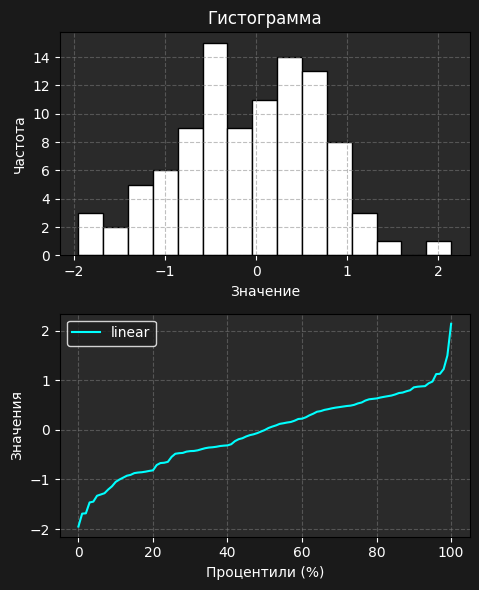

### Функция `numpy.quantile`

```python
numpy.quantile(a, q, axis=None, out=None, overwrite_input=False, method='linear', keepdims=False)
```

`numpy.quantile` — унарная редукция, которая **вычисляет квантиль элементов массива** вдоль указанных осей.

- `q` — доля (`0 - 1`)
- `overwrite_input` — оптимизационная опция. Позволяет использовать сам массив для временных перестановок элементов, вместо создания копии, чтобы сохранить память. Если `True`, **может менять исходный массив**.
- `method` — определяет метод для вычислния процентиля. Существует много различных методов:
    - `inverted_cdf`
    - `averaged_inverted_cdf`
    - `closest_observation`
    - `interpolated_inverted_cdf`
    - `hazen`
    - `weibull`
    - `linear` (по умолчанию) — для обратной совместимости также доступны дискретные варианты:
        - `lower`
        - `higher`
        - `midpoint`
        - `nearest`
    - `median_unbiased`
    - `normal_unbiased`

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

# --- Нормальное распределение ---
a = rng.normal(loc=0, scale=1, size=100)
p = np.linspace(0, 1, 101)
q = np.quantile(a, p, method='linear')

# --- Два подграфика ---
fig, (ax_hist, ax) = plt.subplots(2, 1, figsize=(5, 6), sharex=False,
                                  gridspec_kw={'height_ratios': [1, 1]})
fig.patch.set_facecolor('#1a1a1a')

# --- Гистограмма ---
ax_hist.set_facecolor('#2a2a2a')
ax_hist.grid(True, color='gray', linestyle='--', alpha=0.5)
ax_hist.tick_params(colors='white')
ax_hist.hist(a, bins=60, color='white', edgecolor='black', alpha=1)
ax_hist.set_title('Гистограмма', color='white')
ax_hist.set_xlabel('Значение', color='white')
ax_hist.set_ylabel('Частота', color='white')

# --- График процентилей ---
ax.set_facecolor('#2a2a2a')
ax.grid(True, color='gray', linestyle='--', alpha=0.5)
ax.tick_params(colors='white')
ax.plot(p, q, color='cyan', label='linear')
ax.set_xlabel('Квантили (0 - 1)', color='white')
ax.set_ylabel('Значения', color='white')
ax.legend(facecolor='#1e1e1e', edgecolor='white', labelcolor='white')

plt.tight_layout()
plt.show()


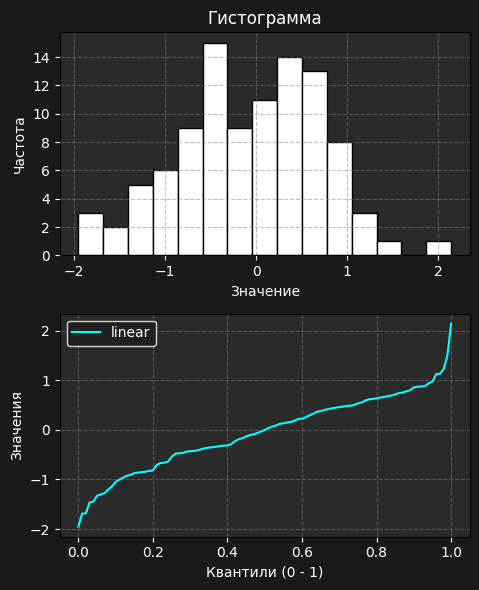

# **Кумулятивные операции**

**Кумулятивные операции** (префиксные операции) — это **унарные операции**, которые применяются к одному массиву, **аккумулируя** значения по определнному правилу.

- Форма может измениться на одномерную при `axis=None`.
- Количество элементов массива остается прежним.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]
# size → 6

np.cumsum(a)
# [ 0,  1,  3,  6, 10]
# size → 6

## Реализации кумулятивных операций 

В NumPy кумулятивные операции реализованы как:

- **Методы массива** — используются почти всегда, если работаем с **конкретным массивом**.
- **Функции верхнего уровня** — используется, когда необходимо работать с **любыми последовательностями**, а не только `ndarray`.
- **NaN-safe функции** — те же самые функции верхнего порядка, но игнорируют `np.nan`.
- **Метод `accumulate` объектов `ufunc`** — используются при написании универсальных функций, когда важна совместимость с любыми `ufunc`.

| Метод массива     | Функция верхнего уровня | NaN-safe функции   | Метод `accumulate` объекта `ufunc` |
| ----------------- | ----------------------- | ------------------ | ---------------------------------- |
| `ndarray.cumsum`  | `numpy.cumsum`          | `numpy.nancumsum`  | `np.add.accumulate`                |
| `ndarray.cumprod` | `numpy.cumprod`         | `numpy.nancumprod` | `np.multiply.accumulate`           |
| -                 | -                       | -                  | `np.minimum.accumulate`            |
| -                 | -                       | -                  | `np.maximum.accumulate`            |
| -                 | -                       | -                  | `np.logical_or.accumulate`         |
| -                 | -                       | -                  | `np.logical_and.accumulate`        |

## Параметры методов 

Кумулятивные операции поддерживают похожий набор **ключевых параметров**.

### Параметр `axis`

Определяет по каким осям выполнять аккумулирование.

- Может быть `None` (по умолчанию для **оберток** — разворачивает массив в одномерный и аккумулирует) или `int` (одна ось)
- Допустимы **отрицательные значения** по аналогии с отрицательными индексами в списках (`axis=-1` — последняя ось)

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

a.cumsum()
# [ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45, 55, 66]

a.cumsum(axis=0)
# [[ 0,  1,  2,  3],
#  [ 4,  6,  8, 10],
#  [12, 15, 18, 21]]

a.cumsum(axis=1)
# [[ 0,  1,  3,  6],
#  [ 4,  9, 15, 22],
#  [ 8, 17, 27, 38]]

### Параметр `dtype`

Определяет тип выходного массива и **промежуточных вычислений**.

- Если `None`, то тип выбирается автоматически.

In [ ]:
import numpy as np

a = np.array([[0.9, 0.9, 0.9], [0.9, 0.9, 0.9]])

np.cumsum(a, dtype=int)  # [0, 0, 0, 0, 0, 0]

### Параметр `out`

Массив, в который будет записан результат.

- **Должен иметь совместимую форму и тип**
- Если `None`, NumPy создает новый массив.
- Если `out` передан, то метод использует **существующее место в памяти**. Это экономит память и ускоряет многократные вычисления.

In [ ]:
import numpy as np

a = np.arange(5)
sum = a.cumsum()  # создается новый объект

b = np.empty_like(a)
a.cumsum(out=b)  # тот же объект

## Кумулятивные методы массива

### Метод `ndarray.cumsum`

```python
ndarray.cumsum(axis=None, dtype=None, out=None)
```

`ndarray.cumsum` — кумулятивная операция, которая вычисляет **кумулятивную сумму элементов массива** вдоль указанной оси.

In [ ]:
import numpy as np

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

a.cumsum()
# [ 0,  1,  3,  6, 10, 15, 21, 28, 36, 45, 55, 66]

a.cumsum(axis=1)
# [[ 0,  1,  3,  6],
#  [ 4,  9, 15, 22],
#  [ 8, 17, 27, 38]]

### Метод `ndarray.cumprod`

```python
ndarray.cumprod(axis=None, dtype=None, out=None)
```

`ndarray.cumprod` — кумулятивная операция, которая вычисляет **кумулятивное произведение элементов массива** вдоль указанной оси.

In [ ]:
import numpy as np

a = np.arange(6).reshape(2, 3)
# [[0 1 2]
#  [3 4 5]]

a.cumprod()
# [0, 0, 0, 0, 0, 0]

a.cumprod(axis=0)
# [[ 0,  1,  2],
#  [ 0,  4, 10]]

## Кумулятивные функции верхнего уровня

Все эти функции реализованы аналогично кумулятивным методам `ndarray`, но сам массив передается первым аргументом:

```python
numpy.cumsum(a, axis=None, dtype=None, out=None)
numpy.cumprod(a, axis=None, dtype=None, out=None)
```

# **Работа с пропущенными значениями**

В чистом NumPy работа с пропущенными значениями **ограничена**, потому что у библиотеки нет отдельного типа для `NaN`.

## Специальное значение `np.nan`

Для обозначения пропущенных или недопуспных данных в числовых массивах используют `np.nan`.

- Имеет тип `float`.
- Никогда не равен самому себе.
- Любые арифметические вычисления с `np.nan` будут возвращать `np.nan`.

In [ ]:
import numpy as np

a = np.array([1, 2, np.nan, 4, 5], dtype=np.float32)
# [ 1.  2. nan  4.  5.]

b = a ** 2
# [ 1.,  4., nan, 16., 25.]

np.nan == np.nan
# False

Нельзя использовать `np.nan` в массивах типа `int`, `str` и т.д. Там делают:

- массив типа `object` и кладут `None`/`np.nan`
- применяют `numpy.ma.MaskedArray` (маскированные массивы)

## Проверка пропусков

### Функция `np.isnan`

```python
numpy.isnan(x, /, out=None, *, where=True)
```

Возвращает булев массив (маску), где `True` — это элементы `np.nan`.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 100, 16).reshape(4, 4).astype(np.float32)

rows = rng.integers(0, 4, 4)
columns = rng.integers(0, 4, 4)
a[rows, columns] = np.nan
# [[ 8. nan 65. 43.]
#  [43. 85.  8. nan]
#  [20.  9. nan 97.]
#  [nan 76. 71. 78.]]

a_filled = np.where(np.isnan(a), np.int32(np.nanmean(a, axis=1, keepdims=True)), a)
# [[ 8. 38. 65. 43.]
#  [43. 85.  8. 45.]
#  [20.  9. 42. 97.]
#  [75. 76. 71. 78.]]

### Функция `np.isfinite`

```python
numpy.isfinite(x, /, out=None, *, where=True)
```

Возвращает булев массив (маску), где `False` — это элементы, **не являющиеся числами** (`np.nan`, `np.inf`, `-np.inf`).

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 100, 16).reshape(4, 4).astype(np.float32)

rows = rng.integers(0, 4, 4)
columns = rng.integers(0, 4, 4)
a[rows, columns] = np.nan
# [[ 8. nan 65. 43.]
#  [43. 85.  8. nan]
#  [20.  9. nan 97.]
#  [nan 76. 71. 78.]]

a_filled = np.where(np.isnan(a), np.int32(np.nanmean(a, axis=1, keepdims=True)), a)
# [[ 8. 38. 65. 43.]
#  [43. 85.  8. 45.]
#  [20.  9. 42. 97.]
#  [75. 76. 71. 78.]]

## Игнорирование пропусков

В NumPy большая часть унарных редукций и кумулятивных операций повторяется в виде **NaN-safe функций**, которые игнорируют `np.nan` при вычислениях:

- Унарные редукции

```python
numpy.nansum(a, axis=None, dtype=None, out=None, keepdims=False, initial=0, where=True)
numpy.nanprod(a, axis=None, dtype=None, out=None, keepdims=False, initial=1, where=True)
numpy.nanmean(a, axis=None, dtype=None, out=None, keepdims=False, *, where=True)
numpy.nanvar(a, axis=None, dtype=None, out=None, ddof=0, keepdims=False, *, where=True, mean=..., correction=...)
numpy.nanstd(a, axis=None, dtype=None, out=None, ddof=0, keepdims=None, *, where=True, mean=..., correction=...)
numpy.nanmin(a, axis=None, out=None, keepdims=False, initial=..., where=True)
numpy.nanmax(a, axis=None, out=None, keepdims=False, initial=..., where=True)
numpy.nanargmin(a, axis=None, out=None, *, keepdims=False)
numpy.nanargmax(a, axis=None, out=None, *, keepdims=False)
numpy.ptp(a, axis=None, out=None, keepdims=False)
numpy.median(a, axis=None, out=None, overwrite_input=False, keepdims=False)
numpy.percentile(a, q, axis=None, out=None, overwrite_input=False, method='linear', keepdims=False)
numpy.quantile(a, q, axis=None, out=None, overwrite_input=False, method='linear', keepdims=False)
```

- Кумулятивные операции

```python
numpy.nancumsum(a, axis=None, dtype=None, out=None, keepdims=False, initial=0, where=True)
numpy.nancumprod(a, axis=None, dtype=None, out=None, keepdims=False, initial=1, where=True)
```

# **Генерация случайных данных**

В NumPy генерация случайных данных происходит через модуль `numpy.random`, который реализует **псевдослучайный генератор чисел (RNG)**.

## Создание генератора

### Функция `numpy.random.default_rng`

```python
numpy.random.default_rng(seed)
```

Функция создает экземпляр генератора с фиксированным `seed`.

- Если не передать этот параметр, то `seed` при каждом выполении будет случайным.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

## Базовые случайные числа

### Метод `rng.random`

```python
rng.random(size)
```

Генерирует массив случайных чисел в диапазоне `[0, 1)` и размером `size`.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

rng.random(6)
# [0.77395605 0.43887844 0.85859792 0.69736803 0.09417735 0.97562235]

### Метод `rng.integers`

```python
rng.integers(low, high, size)
```

Генерирует массив случайных целых чисел в диапазоне `[low, high)` и размером `size`.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

rng.integers(0, 3, 6)
# [0, 2, 1, 1, 1, 2]

## Распределения

### Нормальное распределение

```python
rng.normal(loc, scale, size)
```

Генерирует массив случайной выборки из нормального распределения.

- `loc` — **mean** (математическое ожидание)
- `scale` — **standard deviation** (стандартное отклонение)
- `size` — размер выборки

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

a = rng.normal(loc=0, scale=1, size=1000)

# --- Гистограмма ---
fig, ax_hist = plt.subplots(1, 1, figsize=(5, 4), sharex=False)
fig.patch.set_facecolor('#1a1a1a')

ax_hist.set_facecolor('#2a2a2a')
ax_hist.grid(True, color='gray', linestyle='--', alpha=0.5)
ax_hist.tick_params(colors='white')
ax_hist.hist(a, bins=30, color='white', edgecolor='black', alpha=1)
ax_hist.set_title('Гистограмма', color='white')
ax_hist.set_xlabel('Значение', color='white')
ax_hist.set_ylabel('Частота', color='white')

plt.tight_layout()
plt.show()

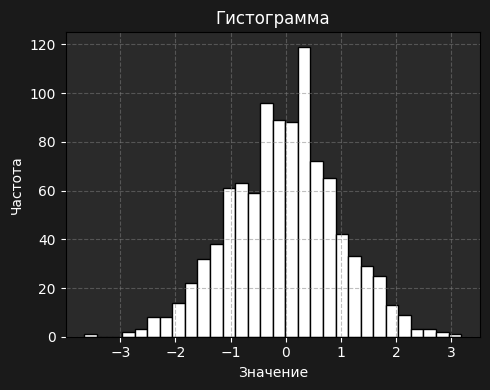

### Равномерное распределение

```python
rng.uniform(low, high, size)
```

Генерирует массив случайной выборки из равномерного распределения.

- `low` — минимальное значение
- `high` — максимальное значение
- `size` — размер выборки

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

a = rng.uniform(low=-1, high=1, size=1000)

# --- Гистограмма ---
fig, ax_hist = plt.subplots(1, 1, figsize=(5, 4), sharex=False)
fig.patch.set_facecolor('#1a1a1a')

ax_hist.set_facecolor('#2a2a2a')
ax_hist.grid(True, color='gray', linestyle='--', alpha=0.5)
ax_hist.tick_params(colors='white')
ax_hist.hist(a, bins=16, color='white', edgecolor='black', alpha=1)
ax_hist.set_title('Гистограмма', color='white')
ax_hist.set_xlabel('Значение', color='white')
ax_hist.set_ylabel('Частота', color='white')

plt.tight_layout()
plt.show()

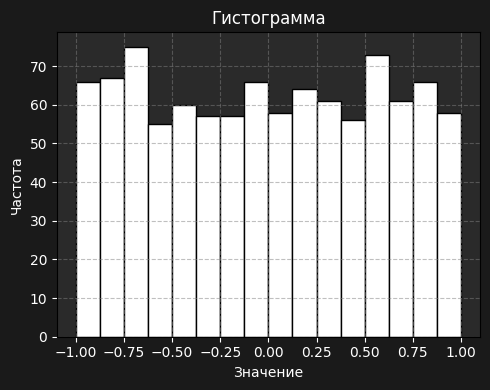

### Биноминальное распределение

```python
rng.binomial(n, p, size)
```

Генерирует массив случайной выборки из биноминального распределения.

- `n` — число испытаний
- `p` — вероятность успеха
- `size` — размер выборки

При `n=1` — распределение Бернулли.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

a = rng.binomial(n=10, p=0.5, size=1000)

# --- Гистограмма ---
fig, ax_hist = plt.subplots(1, 1, figsize=(5, 4), sharex=False)
fig.patch.set_facecolor('#1a1a1a')

ax_hist.set_facecolor('#2a2a2a')
ax_hist.grid(True, color='gray', linestyle='--', alpha=0.5)
ax_hist.tick_params(colors='white')
ax_hist.hist(a, bins=10, color='white', edgecolor='black', alpha=1)
ax_hist.set_title('Гистограмма', color='white')
ax_hist.set_xlabel('Значение', color='white')
ax_hist.set_ylabel('Частота', color='white')

plt.tight_layout()
plt.show()

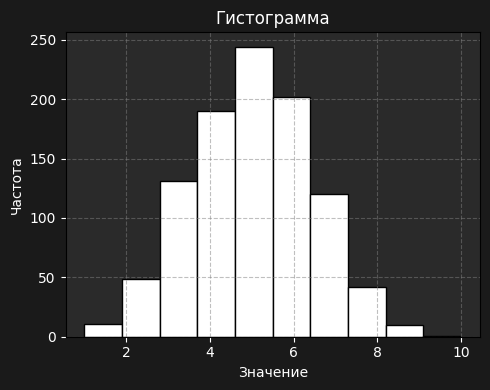

### Пуассоновское распределение

```python
rng.poisson(lam, size)
```

Генерирует массив случайной выборки из пуассоновского распределения.

- `lam` — среднее число событий за фиксированный промежуток времени
- `size` — размер выборки

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

a = rng.poisson(lam=3, size=1000)

# --- Гистограмма ---
fig, ax_hist = plt.subplots(1, 1, figsize=(5, 4), sharex=False)
fig.patch.set_facecolor('#1a1a1a')

ax_hist.set_facecolor('#2a2a2a')
ax_hist.grid(True, color='gray', linestyle='--', alpha=0.5)
ax_hist.tick_params(colors='white')
ax_hist.hist(a, bins=10, color='white', edgecolor='black', alpha=1)
ax_hist.set_title('Гистограмма', color='white')
ax_hist.set_xlabel('Значение', color='white')
ax_hist.set_ylabel('Частота', color='white')

plt.tight_layout()
plt.show()

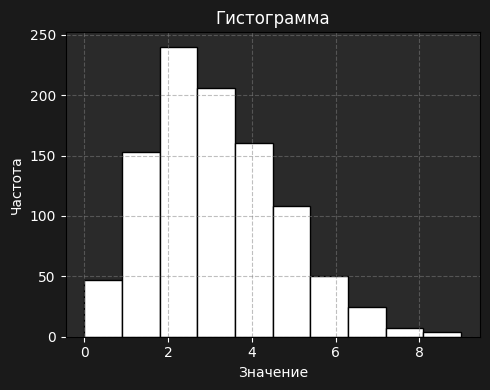

## Случайные выборки и перестановки

### Метод `rng.choice`

```python
rng.choice(a, size=None, replace=True, p=None, axis=None)
```

Генерирует массив случайной выборки из элементов `a`.

- `a` — массив или целое число (`0...a-1`)
- `size` — форма выходного массива
- `replace` — если `False`, то выбор без повторений
- `p` — массив вероятностей для каждого элемента. Если не указан, то считается, что распределение равномерное. По размеру должен совпадать с `a`.
- `axis` — вдоль какой оси выбирать элементы. Если `None`, работает как `axis=0`.

In [ ]:
import numpy as np

rng = np.random.default_rng(seed=42)

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

rng.choice(a, 2, replace=False)
# [[ 0  1  2  3]
#  [ 8  9 10 11]]

rng.choice(a, 4, replace=True)
# [[ 4,  5,  6,  7],
#  [ 4,  5,  6,  7],
#  [ 8,  9, 10, 11],
#  [ 0,  1,  2,  3]]

rng.choice(a, (2, 2), replace=True)
# [[[ 8,  9, 10, 11],
#   [ 0,  1,  2,  3]],
#
#  [[ 0,  1,  2,  3],
#   [ 4,  5,  6,  7]]]

Примеры с вероятностью:

In [ ]:
import numpy as np

rng = np.random.default_rng(seed=42)

a = np.arange(5)
# [0 1 2 3 4]

p = [0.5, 0.3, 0, 0, 0.2]

rng.choice(a, 10, p=p)
# [1, 0, 4, 1, 0, 4, 1, 1, 0, 0]

rng.choice(a, (2, 5), p=p)
# [[0, 4, 1, 4, 0],
#  [0, 1, 0, 4, 1]]

Примеры с осями:

In [ ]:
import numpy as np

rng = np.random.default_rng(seed=42)

a = np.arange(12).reshape(3, 4)
# [[ 0  1  2  3]
#  [ 4  5  6  7]
#  [ 8  9 10 11]]

rng.choice(a, 2, replace=False, axis=0)
# [[ 0,  1,  2,  3],
#  [ 8,  9, 10, 11]]

rng.choice(a, 2, replace=False, axis=1)
# [[ 0,  3],
#  [ 4,  7],
#  [ 8, 11]]

rng.choice(a, (1, 2), replace=False, axis=1)
# [[[ 1,  3]],
#
#  [[ 5,  7]],
#
#  [[ 9, 11]]]

### Метод `rng.permutation`

```python
rng.permutation(a, axis=0)
```

Генерирует массив, в котором меняет местами элементы массива `a`.

- `axis` — вдоль какой оси выполнять перестановки (по умолчанию передвигает строки).

In [ ]:
import numpy as np

rng = np.random.default_rng(seed=42)

a = np.arange(9).reshape(3, 3)
# [[0 1 2]
#  [3 4 5]
#  [6 7 8]]

rng.permutation(a)
# [[6, 7, 8],
#  [3, 4, 5],
#  [0, 1, 2]]

rng.permutation(a, axis=1)
# [[0, 2, 1],
#  [3, 5, 4],
#  [6, 8, 7]]

# **Линейная алгебра**

Операции над матрицами и векторами реализованы в модуле `numpy.linalg`.

## Определитель матрицы

```python
linalg.det(a)
```

Вычисляет определитель матрицы `a`.

- Вычисление происходит через **LU-разложение**. Из-за этого может возникнуть артефакт вычислений с плавающей точкой.

In [ ]:
import numpy as np

rng = np.random.default_rng(42)

a = rng.integers(0, 10, 9).reshape(3, 3)
# [[0 7 6]
#  [4 4 8]
#  [0 6 2]]

np.linalg.det(a)
# 87.99999999999996

## Обратная матрица

```python
linalg.inv(a)
```

Вычисляет обратную матрицу `a`.

- Вычисление происходит через **LU-разложение**. Из-за этого может возникнуть артефакт вычислений с плавающей точкой.
- Возвращает массив с типом `np.float64`

In [ ]:
import numpy as np

a = np.array([[1, 2, 3], [0, 1, 4], [5, 6, 0]])
# [[1 2 3]
#  [0 1 4]
#  [5 6 0]]

np.linalg.inv(a)
# [[-24.,  18.,   5.],
#  [ 20., -15.,  -4.],
#  [ -5.,   4.,   1.]]

## Норма вектора и матрицы

```python
linalg.norm(x, ord=None, axis=None, keepdims=None)
```

Вычисляет норму вектора или матрицы `x`.

- `ord` — тип нормы (`1`, `2,`, `np.inf` и т.д.)
- `axis` — вдоль каких осей считать (одна ось → векторная норма, две оси → матричная)
- `keepdims` — если `True`, то не редуцирует массив

Если `x` — это вектор, то:

In [ ]:
import numpy as np

a = np.array([3, 4])
# [3, 4]

np.linalg.norm(a, 1)  # сумма модулей
# 7.0

np.linalg.norm(a, 2)  # евклидова норма
# 5.0

np.linalg.norm(a, np.inf)  # максимум модуля
# 4.0

Если `x` — это матрица, то:

In [ ]:
import numpy as np

b = np.array([[1, 2], [3, 4]])
# [[1, 2]
#  [3, 4]]

np.linalg.norm(b, 1)  # максимум по столбцовым суммам
# 6.0

np.linalg.norm(b, np.inf)  # максимум по строковым суммам
# 7.0

np.linalg.norm(b, 2)  # спектральная норма
# 5.464985704219043

## Ранг матрицы

```python
linalg.matrix_rank(A, tol=None)
```

Вычисляет ранг матрицы `A`.

- Вычисление происходит через **SVD**.
- `tol` — порог для сингулярных чисел: числа меньше `tol` считаются нулевыми. При `None` это число будет рассчитано автоматически.

In [ ]:
import numpy as np

A = np.array([[1, 2], [3, 4]])
# [[1, 2]
#  [3, 4]]

np.linalg.matrix_rank(A)
# 2

B = np.vstack((A, A))
# [[1 2]
#  [3 4]
#  [1 2]
#  [3 4]]

np.linalg.matrix_rank(B)
# 2

## Собственные значения и собственные векторы

```python
vals, vecs = linalg.eig(a)
```

Вычисляет собственные значение и собственные векторы квадратной матрицы `a`.

- `vals` — массив собственных значений
- `vecs` — массив собсвтенных векторов
- Вычисление включает **Hessenberg form** и **QR-алгоритм**. Из-за этого может возникнуть артефакт вычислений с плавающей точкой.

In [ ]:
import numpy as np

a = np.arange(9).reshape(3, 3)
# [[0 1 2]
#  [3 4 5]
#  [6 7 8]]

vals, vecs = np.linalg.eig(a)
# [ 1.33484692e+01 -1.34846923e+00 -2.48477279e-16]

# [[ 0.16476382  0.79969966  0.40824829]
#  [ 0.50577448  0.10420579 -0.81649658]
#  [ 0.84678513 -0.59128809  0.40824829]]

<div style="
  border: 1.5px solid #569CD6;
  background-color: #1E1E2E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #9CDCFE;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🧠 **Вопрос**

Почему в примере выше у линейно зависимой матрицы ни одно из собственных значений не было равно `0`?

<details><summary>ОТВЕТ</summary>

Из-за **QR-алгоритма** с вычислениями в `np.float64` присутствует погрешность.

</details>
</div>

## Singular Value Decomposition (SVD)

```python
U, S, Vh = np.linalg.svd(A)
```

Функция для сигнулярного разложения (SVD) матрицы.

In [ ]:
import numpy as np

A = np.array([[1,2,3],
              [4,5,6],
              [7,8,9]])

U, S, Vh = np.linalg.svd(A)
# [[-0.21483724  0.88723069  0.40824829]
#  [-0.52058739  0.24964395 -0.81649658]
#  [-0.82633754 -0.38794278  0.40824829]]

# [1.68481034e+01 1.06836951e+00 4.41842475e-16]

# [[-0.47967118 -0.57236779 -0.66506441]
#  [-0.77669099 -0.07568647  0.62531805]
#  [-0.40824829  0.81649658 -0.40824829]]

# **Универсальные функции**

**Универсальная функция** `ufunc` (universal func) — это специальный объект, **обёртка** внутри быстрого C-кода, которая позволяет применять функцию **сразу ко всем элементам массива** без явных циклов на Python.

<div style="
  border: 1.5px solid #D7BA7D;
  background-color: #2E2A1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #FFEFC1;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

💡 **Интересный факт**

`ufunc` — это **универсальная функция для массивов**.

Она позволяет писать **векторизованный код** вместо циклов Python, что делает вычисления в NumPy очень быстрыми.

</div>

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

У `ufunc.reduce` у каждого `ufunc` своё поведение по умолчанию. Без явного указания `axis` часто используется `axis=0`, что может быть **не совсем очевидно**, если сравнивать с методами массива `ndarray` или функциями верхнего уровня `numpy`.

</div>


## Параметры функций

Все универсальные функции обладают следующими параметрами:

- `out` — позволяет указать в какую переменную будет записан **результат выполнения функции**. Для некоторых функций есть ограничение на тип переменной, которая передает в качестве аргумента. Форма массива также должна соответствовать форме результирующего массива.
- `where` — позволяет указать **для каких именно** элементов массива применить функцию. Передаваемый аргумент должен иметь ту же форму, что и массив, который изменяется функцией.

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

Методы `ufunc.reduce` всех универсальных функций **по умолчанию редуцируют по первой оси**, а не по всему массиву.

</div>


In [ ]:
import numpy as np

a = np.arange(10).reshape(2, 5)

a.sum()           # 45
np.add.reduce(a)  # [ 5,  7,  9, 11, 13]

## Свойства

- Элементно-ориентированные операции

In [ ]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([4, 2, 6])

np.add(a, b)    # [5 4 9]
np.equal(a, b)  # [False  True False]

- Работают с любыми совместимыми формами (broadcasting)

In [ ]:
import numpy as np

a = [1, 2, 3]              # [1 2 3]

np.add(a, 10)              # [11 12 13]

np.subtract(a, [3, 3, 3])  # [-2, -1,  0]

- Поддержка аккумуляторов

Некоторые `ufunc` могут использоваться для редукции по оси (`ufunc.reduce`) или для кумулятивных вычислений (`ufunc.accumulate`):

In [ ]:
import numpy as np

arr = np.array([1, 2, 3, 4])

np.add.reduce(arr)
# 10

np.multiply.accumulate(arr)
# [1 2 6 24]

## Экземпляры класса `ufunc`

### `numpy.add`

```python
numpy.add(x1, x2, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию сложения**: берет два массива и поэлементно складывает их.

In [ ]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

np.add(a, b)
# [11 22 33]

### `numpy.subtract`

```python
numpy.subtract(x1, x2, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию вычитания**: берет два массива и поэлементно вычитает элементы второго массива из первого.

In [ ]:
import numpy as np

a = np.array([10, 20, 30])
b = np.array([1, 2, 3])

np.subtract(a, b)
# [ 9 18 27]

### `numpy.multiply`

```python
numpy.multiply(x1, x2, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию умножения**: берет два массива и поэлементно перемножает их элементы.

In [ ]:
import numpy as np

a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

np.multiply(a, b)
# [10 40 90]

### `numpy.divide`

```python
numpy.divide(x1, x2, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию деления**: берет два массива и поэлементно делит элементы первого массива на элементы второго.

In [ ]:
import numpy as np

a = np.array([10, 20, 30])
b = np.array([2, 5, 10])

np.divide(a, b)
# [5. 4. 3.]

### `numpy.divmod`

```python
numpy.divmod(x1, x2, out=None)
```

Представляет **универсальную функцию целочисленного деления и остатка**: берет два массива и возвращает кортеж `(quotient, remainder)`, где:

- `quotient` — целая часть деления
- `remainder` — остаток от деления

In [ ]:
import numpy as np

a = np.array([10, 20, 30])
b = np.array([3, 6, 4])

quotient, remainder = np.divmod(a, b)
# [3 3 7]

# [1 2 2]

### `numpy.sin`

```python
numpy.sin(x, out=None, *, where=True, dtype=None)
```

Представляет **универсальную тригонометрическую функцию синуса**: поэлементно вычисляет синус каждого элемента массива (в радианах).

- Из-за погрешностей при работе с числами с плавающей точкой могут возникать артефакты.

In [ ]:
import numpy as np

a = np.array([0, np.pi / 2, np.pi])

np.sin(a)
# [0.0000000e+00 1.0000000e+00 1.2246468e-16]

### `numpy.cos`

```python
numpy.cos(x, out=None, *, where=True, dtype=None)
```

Представляет **универсальную тригонометрическую функцию косинуса**: поэлементно вычисляет косинус каждого элемента массива (в радианах).

- Из-за погрешностей при работе с числами с плавающей точкой могут возникать артефакты.

In [ ]:
import numpy as np

a = np.array([0, np.pi / 2, np.pi])

np.cos(a)
# [ 1.0000000e+00  6.1232340e-17 -1.0000000e+00]

### `numpy.sqrt`

```python
numpy.sqrt(x, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию квадратного корня**: поэлементно вычисляет квадратный корень каждого элемента массива.

In [ ]:
import numpy as np

a = np.array([1, 4, 9, 16])

np.sqrt(a)
# [1. 2. 3. 4.]

### `numpy.exp`

```python
numpy.exp(x, out=None, *, where=True, dtype=None)
```

Представляет **универсальную экспоненциальную функцию**: поэлементно вычисляет $e^x$ для каждого элемента массива.

In [ ]:
import numpy as np

a = np.array([0, 1, 2])

np.exp(a)
# [ 1.          2.71828183  7.3890561 ]

### `numpy.negative`

```python
numpy.negative(x, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию отрицания**: поэлементно меняет знак каждого элемента массива на противоположный.

In [ ]:
import numpy as np

a = np.array([1, -2, 3, -4])

np.negative(a)
# [-1  2 -3  4]

### `numpy.round`

```python
numpy.round(x, decimals=0, out=None)
```

Представляет **универсальную функцию округления**: поэлементно округляет элементы массива до указанного числа десятичных знаков (`decimals`).

- `decimals=0` — округление до целого числа по умолчанию.

In [ ]:
import numpy as np

a = np.array([1.2, 2.5, 3.7])

np.round(a)
# [1. 2. 4.]

np.round(a, decimals=1)
# [1.2 2.5 3.7]

### `numpy.minimum`

```python
numpy.minimum(x1, x2, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию поэлементного выбора минимума**: сравнивает элементы двух массивов и возвращает новый массив, где каждый элемент — минимальное значение из соответствующих элементов `x1` и `x2`.

In [ ]:
import numpy as np

a = np.array([1, 4, 3])
b = np.array([2, 2, 5])

np.minimum(a, b)
# [1 2 3]

### `numpy.maximum`

```python
numpy.maximum(x1, x2, out=None, *, where=True, dtype=None)
```

Представляет **универсальную функцию поэлементного выбора максимума**: сравнивает элементы двух массивов и возвращает новый массив, где каждый элемент — максимальное значение из соответствующих элементов `x1` и `x2`.

In [ ]:
import numpy as np

a = np.array([1, 4, 3])
b = np.array([2, 2, 5])

np.maximum(a, b)
# [2 4 5]

### `numpy.logical_and`

```python
numpy.logical_and(x1, x2, out=None, *, where=True)
```

Представляет **универсальную логическую функцию "И"**: поэлементно возвращает `True`, если оба элемента из `x1` и `x2` истинны, иначе `False`.

- Работает с любыми типами, которые можно интерпретировать как булевы значения.

In [ ]:
import numpy as np

a = np.array([True, False, True, False])
b = np.array([True, True, False, False])

np.logical_and(a, b)
# [ True False False False]

### `numpy.logical_or`

```python
numpy.logical_or(x1, x2, out=None, *, where=True)
```

Представляет **универсальную логическую функцию "ИЛИ"**: поэлементно возвращает `True`, если хотя бы один из элементов `x1` и `x2` истинный, иначе `False`.

- Работает с любыми типами, которые можно интерпретировать как булевы значения.

In [ ]:
import numpy as np

a = np.array([True, False, True, False])
b = np.array([True, True, False, False])

np.logical_or(a, b)
# [ True  True  True False]

### `numpy.logical_not`

```python
numpy.logical_not(x, out=None, *, where=True)
```

Представляет **универсальную логическую функцию отрицания**: поэлементно возвращает `True`, если элемент `x` ложный, и `False`, если элемент истинный.

In [ ]:
import numpy as np

a = np.array([True, False, 0, 1])
np.logical_not(a)
# [False  True  True False]

### `numpy.logical_xor`

```python
numpy.logical_xor(x1, x2, out=None, *, where=True)
```

Представляет **универсальную логическую функцию "исключающее ИЛИ"**: поэлементно возвращает `True`, если ровно один из элементов `x1` и `x2` истинный, иначе `False`.

- Работает с любыми типами, которые можно интерпретировать как булевы значения.

In [ ]:
import numpy as np

a = np.array([True, False, True, False])
b = np.array([True, True, False, False])

np.logical_xor(a, b)
# [False  True  True False]

## Методы класса

### Метод `ufunc.reduce`

```python
ufunc.reduce(a, axis=0, dtype=None, out=None, keepdims=False, initial=<no value>)
```

Позволяет свернуть массив по оси, **последовательно применяя `ufunc` к элементам массива**.

In [ ]:
import numpy as np

arr = np.array([[1, 2, 3], [4, 5, 6]])
# [[1 2 3]
#  [4 5 6]]

np.add.reduce(arr, axis=0)
# [5 7 9]

np.add.reduce(arr, axis=1, initial=100)
# [106 115]

### Метод `ufunc.accumulation`

```python
ufunc.accumulate(a, axis=0, dtype=None, out=None)
```

**Выполняет кумулятивную (поэлементную) операцию `ufunc` по указанной оси**: результатом является массив той же формы, где каждый элемент — накопленное применение операции до этого элемента.

In [ ]:
import numpy as np

arr = np.array([[1, 2, 3], [4, 5, 6]])
# [[1 2 3]
#  [4 5 6]]

np.add.accumulate(arr, axis=0)
# [[1 2 3]
#  [5 7 9]]

np.add.accumulate(arr, axis=1)
# [[ 1  3  6]
#  [ 4  9 15]]

## Создание своей универсальной функции

Собственную `ufunc`, которая будет работать поэлементно, можно создать с помощью:

- C-расширений
- функции `numpy.fromfunc`

### Функция `numpy.fromfunc`

```python
numpy.frompyfunc(func, / nin, nout)
```

Функция возвращает `ufunc`, которую можно применять к массивам и скалярам.

- `func` — обычная Python-функция
- `nin` — количество входных аргументов функции
- `nout` — количество выходных аргументов функции

<div style="
  border: 1.5px solid #D16969;
  background-color: #2A1E1E;
  padding: 12px 16px;
  border-radius: 6px;
  color: #F9D2D2;
  width: auto;
  max-width: 100%;
  overflow-wrap: break-word;
  box-sizing: border-box;
">

🔥 **Важно**

Всегда возвращает объект `ufunc`, который всегда возвращает массив типа `object`. Если нужны конкретные типы, лучше использовать `numpy.vectorize`.

</div>


In [ ]:
import numpy as np

def only_even_values(x: int) -> int:
    return x if x % 2 == 0 else x + 1

uf = np.frompyfunc(only_even_values, 1, 1)

a = np.arange(9).reshape(3, 3)
# [[0 1 2]
#  [3 4 5]
#  [6 7 8]]

uf(a)
# [[0, 2, 2],
#  [4, 4, 6],
#  [6, 8, 8]]

### Функция `numpy.vectorize`

```python
numpy.vectorize(pyfunc, otypes=None)
```

Более удобная Python-обертка для `ufunc` с возможностью указать типы выходных данных.

- `pyfunc` — обычная Python-функция
- `otypes` — список типов выходных данных

In [ ]:
import numpy as np

def sort_values(x: int) -> tuple[int, int]:
    return (x % 2 == 0, x % 2 != 0)

uf = np.vectorize(sort_values, otypes=[int, int])

a = np.arange(9).reshape(3, 3)
# [[0 1 2]
#  [3 4 5]
#  [6 7 8]]

even, odd = uf(a)
# [[1 0 1]
#  [0 1 0]
#  [1 0 1]]

# [[0 1 0]
#  [1 0 1]
#  [0 1 0]]